Creating Pivot Tables of Data

In [2]:
import pandas as pd
import numpy as np

In [3]:
xl = pd.read_excel('combined_channels.xlsx', sheet_name=None)
df_all = pd.concat(xl.values(), ignore_index=True)

# drop empty trailing rows that Excel adds on load
df_all = df_all.dropna(subset=['Ch', 'Wheel (counts)'])

# NaN presence forces Ch to float on load, cast back to int
df_all['Ch'] = df_all['Ch'].astype(int)

df_all

,Int,Ch,Date,Time,Wheel (counts),Wheel Accum (counts),Channel_1,Channel_2,Channel_3,Channel_4,Channel_5,Channel_6,Channel_7,Channel_8,Channel_9,Channel_10,hour
0,0.0,1,12/08/2021,10:43:52,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1,12/08/2021,10:48:52,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,1,12/08/2021,10:53:52,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,1,12/08/2021,10:58:52,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,1,12/08/2021,11:03:52,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144165,2002.0,10,01/27/2022,12:00:08,0.0,4221.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144166,2003.0,10,01/27/2022,12:05:08,0.0,4221.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144167,2004.0,10,01/27/2022,12:10:08,0.0,4221.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144168,2005.0,10,01/27/2022,12:15:08,0.0,4221.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_all['datetime'] = pd.to_datetime(
    df_all['Date'].astype(str) + ' ' + df_all['Time'].astype(str),
    format='%m/%d/%Y %H:%M:%S'
)
df_all['Date'] = df_all['datetime'].dt.date
df_all['hour'] = df_all['datetime'].dt.hour

In [5]:
pv_daily = pd.pivot_table(
    df_all,
    values='Wheel (counts)',
    index='Date',
    columns='Ch',
    aggfunc='sum',
    fill_value=0
)
pv_daily.columns = [f'Channel_{c}' for c in pv_daily.columns]
pv_daily = pv_daily.sort_index()
pv_daily

,Channel_1,Channel_2,Channel_3,Channel_4,Channel_5,Channel_6,Channel_7,Channel_8,Channel_9,Channel_10
Date,,,,,,,,,,
2021-12-08,43.0,7.0,2946.0,2465.0,2392.0,1318.0,193.0,992.0,1984.0,256.0
2021-12-09,0.0,0.0,1337.0,1587.0,1606.0,683.0,2511.0,1491.0,1875.0,31.0
2021-12-10,0.0,0.0,1978.0,1169.0,438.0,1125.0,661.0,625.0,1786.0,121.0
2021-12-11,0.0,100.0,4435.0,4023.0,3710.0,5042.0,6438.0,1979.0,6876.0,675.0
2021-12-12,0.0,70.0,4060.0,4060.0,3893.0,5347.0,6891.0,2661.0,7453.0,523.0
2021-12-13,11.0,33.0,6836.0,2921.0,2503.0,6307.0,6132.0,2682.0,10468.0,751.0
2021-12-14,0.0,7.0,5270.0,3454.0,3360.0,7865.0,7664.0,2706.0,8197.0,875.0
2021-12-15,0.0,29.0,5413.0,3951.0,1406.0,8746.0,7240.0,1687.0,7662.0,872.0
2021-12-16,0.0,25.0,5823.0,3344.0,3631.0,7967.0,6623.0,4350.0,11228.0,809.0


In [6]:
pv_hourly = pd.pivot_table(
    df_all,
    values='Wheel (counts)',
    index='hour',
    columns='Ch',
    aggfunc='sum',
    fill_value=0
)
pv_hourly.columns = [f'Channel_{c}' for c in pv_hourly.columns]
pv_hourly
#hour 0 is midnight, 23 is 11pm

,Channel_1,Channel_2,Channel_3,Channel_4,Channel_5,Channel_6,Channel_7,Channel_8,Channel_9,Channel_10
hour,,,,,,,,,,
0,4236.0,810.0,11410.0,9167.0,4365.0,15413.0,11136.0,5204.0,14676.0,2721.0
1,3457.0,302.0,12494.0,4185.0,5749.0,6573.0,7934.0,2872.0,6575.0,2754.0
2,139.0,414.0,11529.0,1935.0,3511.0,5933.0,7706.0,2778.0,6378.0,1960.0
3,1713.0,2844.0,13668.0,4327.0,5470.0,8979.0,17064.0,4906.0,7299.0,2280.0
4,3564.0,3807.0,26643.0,27994.0,24622.0,27423.0,35294.0,20181.0,18369.0,9892.0
5,5591.0,7096.0,12233.0,28083.0,10550.0,15981.0,35145.0,16776.0,8342.0,7576.0
6,2464.0,3656.0,1562.0,7820.0,1917.0,528.0,6106.0,8329.0,1619.0,359.0
7,2722.0,3043.0,1063.0,363.0,398.0,1406.0,25.0,1776.0,939.0,48.0
8,210.0,55.0,875.0,325.0,265.0,306.0,174.0,631.0,382.0,11.0


Graphing Pivot Tables on Line Graphs

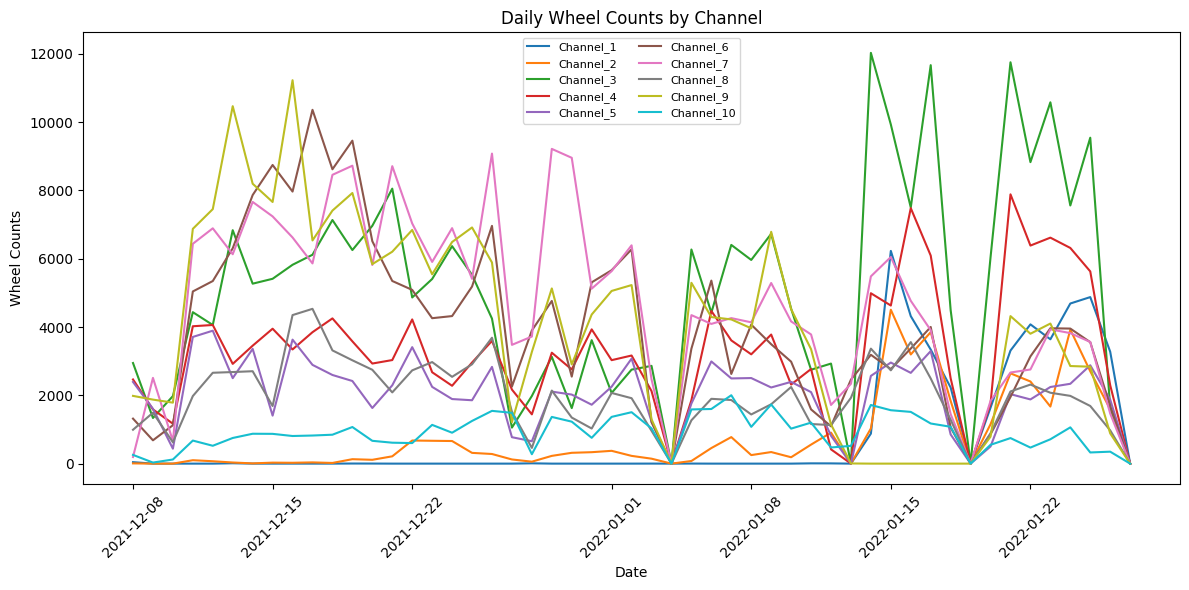

In [7]:
#graph daily pv table with line graph using matplotlib
#each channel should be a different line on the graph
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for channel in pv_daily.columns:
    plt.plot(pv_daily.index, pv_daily[channel], label=channel)
plt.xlabel('Date')
plt.ylabel('Wheel Counts')
plt.title('Daily Wheel Counts by Channel')
plt.legend(ncol=2, fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

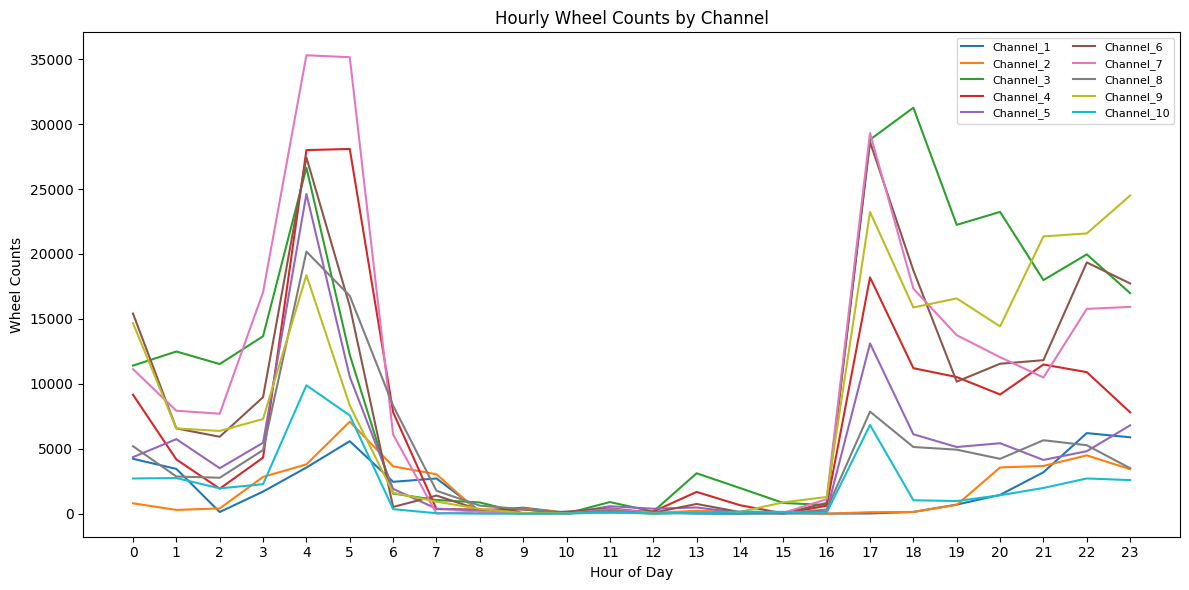

In [8]:
#plot hourly pv table with line graph using matplotlib
#each channel should be a different line on the graph
plt.figure(figsize=(12, 6))
for channel in pv_hourly.columns:
    plt.plot(pv_hourly.index, pv_hourly[channel], label=channel)
plt.xlabel('Hour of Day')
plt.ylabel('Wheel Counts')
plt.title('Hourly Wheel Counts by Channel')
plt.legend(ncol=2, fontsize=8)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()
#hour 0 is midnight, 23 is 11pm

Save Pivot Tables into Same Excel

In [9]:
#save the pv tables to same excel file but as different sheets
with pd.ExcelWriter('combined_channels.xlsx', mode='a', if_sheet_exists='replace') as writer:
    pv_daily.to_excel(writer, sheet_name='pv_daily')
    pv_hourly.to_excel(writer, sheet_name='pv_hourly')
    #the original channel sheets should not be deleted, just add these two new sheets to the same file
    #if this works, pring success message
print('Pivot tables saved to combined_channels.xlsx successfully!')

Pivot tables saved to combined_channels.xlsx successfully!


Cosinor Model (use sine/cosine graph to mad circadian rhythm data)

In [10]:
from scipy.optimize import curve_fit
# fit a sine wave to the hourly pv data for each channel to see if there is a daily rhythm in the wheel running
# MESOR show average activity level (the midline of the wave)
# Amplitude show strength of the day/night contrast (height of the wave)
# Phase show time of peak activity (where the wave peaks on the 24h clock)
# R² tells you how well the cosine shape fits the actual data

# compute mean counts per hour per cage across days
# this gives us the "typical" 24h activity profile for each 
hourly_mean = df_all.groupby(['Ch', 'hour'])['Wheel (counts)'].mean()


In [11]:
def cosinor(t, mesor, amplitude, phase):
    # standard single-component cosinor equation
    return mesor + amplitude * np.cos(2 * np.pi / 24 * (t - phase))

In [12]:
cosinor_results = [] # to store results for each channel

# loop through channels and fit cosinor model to their hourly mean activity
for ch in sorted(df_all['Ch'].unique()):
    t = np.arange(24) # hours 0-23
    y = hourly_mean.loc[ch].values # mean activity for this channel at each hour
    
    # initial guess for perameters --> mesor = mean activity, amplitude = half the range, phase = hour of peak
    # mesor = mean activity, amplitude = half the range, phase = hour of peak
    p0 = [y.mean(), (y.max() - y.min()) / 2, t[np.argmax(y)]]
    

    # fit the cosinor model and extract parameters
    try:
        params, _ = curve_fit(cosinor, t, y, p0=p0, maxfev=5000)
        mesor, amplitude, phase = params
        
        # ensure phase is between 0 and 24 hours
        phase = phase % 24
        
        # compute R² for goodness of fit
        y_pred = cosinor(t, *params)
        r_squared = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
        
        # store results
        cosinor_results.append({
            'channel': ch,
            'mesor': round(mesor, 3),
            'amplitude': round(amplitude, 3),
            'phase': round(phase, 3),
            'r_squared': round(r_squared, 3)
        })

    # if fit fails print message but continue with next channel
    except RuntimeError:
        print(f'Channel {ch}: cosinor fit did not converge')

cosinor_df = pd.DataFrame(cosinor_results).set_index('channel')
print(cosinor_df)

          mesor  amplitude   phase  r_squared
channel                                      
1         2.958      3.602   1.088      0.554
2         2.727      2.735   1.922      0.353
3        18.037     18.208  21.724      0.567
4        11.616      8.832   0.086      0.216
5         7.239      6.205   0.469      0.232
6        14.098     13.773  22.528      0.425
7        16.468     14.090  23.964      0.304
8         7.037      6.274   1.858      0.281
9        14.223     16.940  21.892      0.683
10        3.187      2.971   1.104      0.237


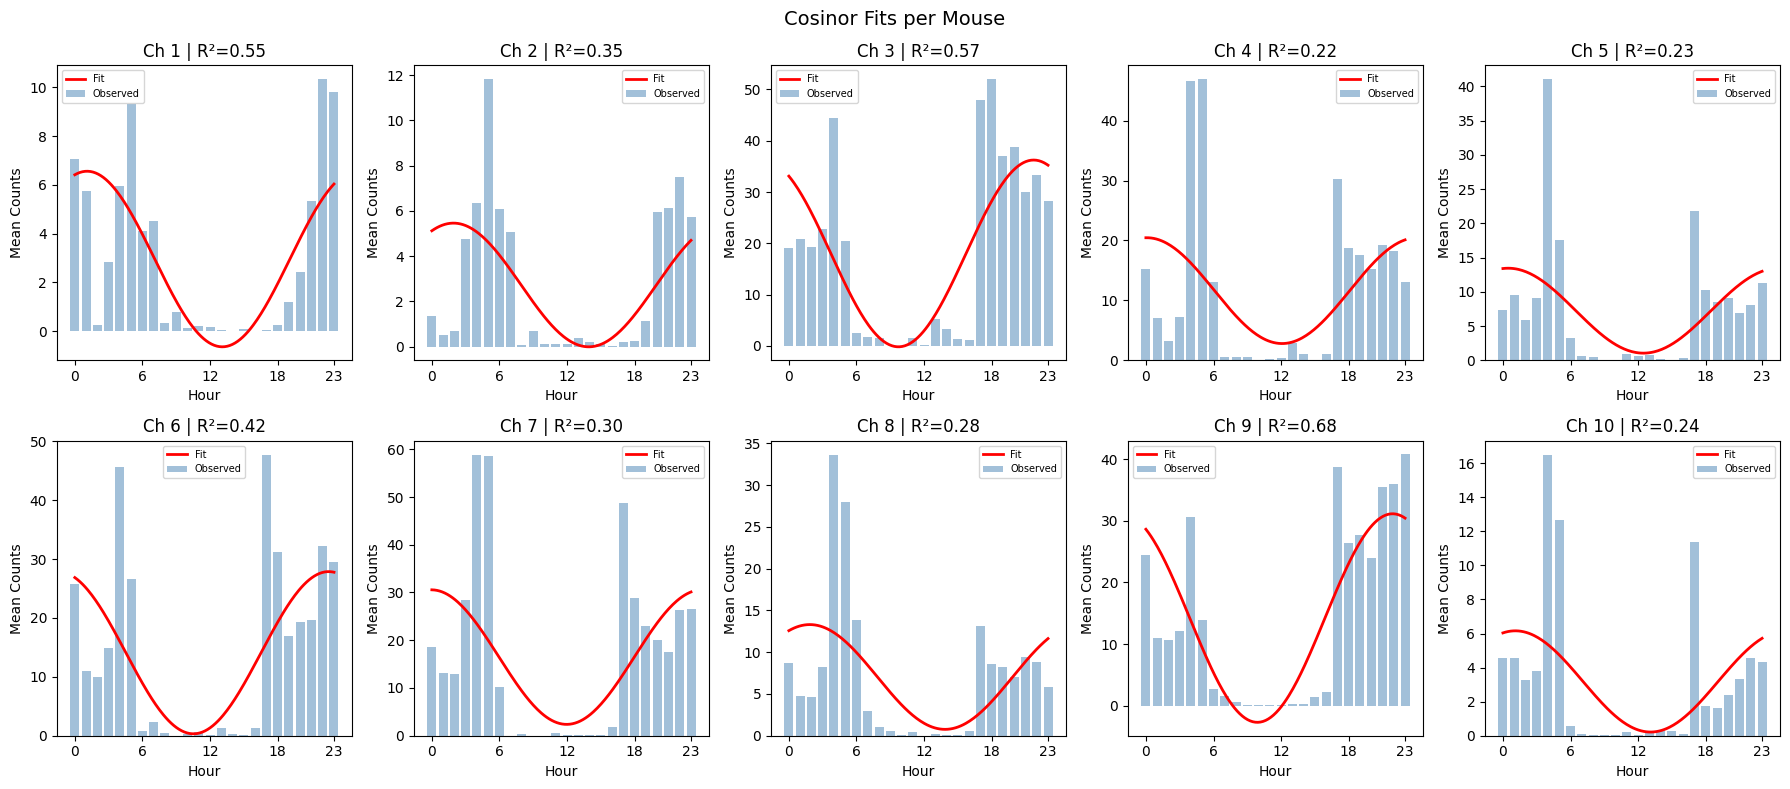

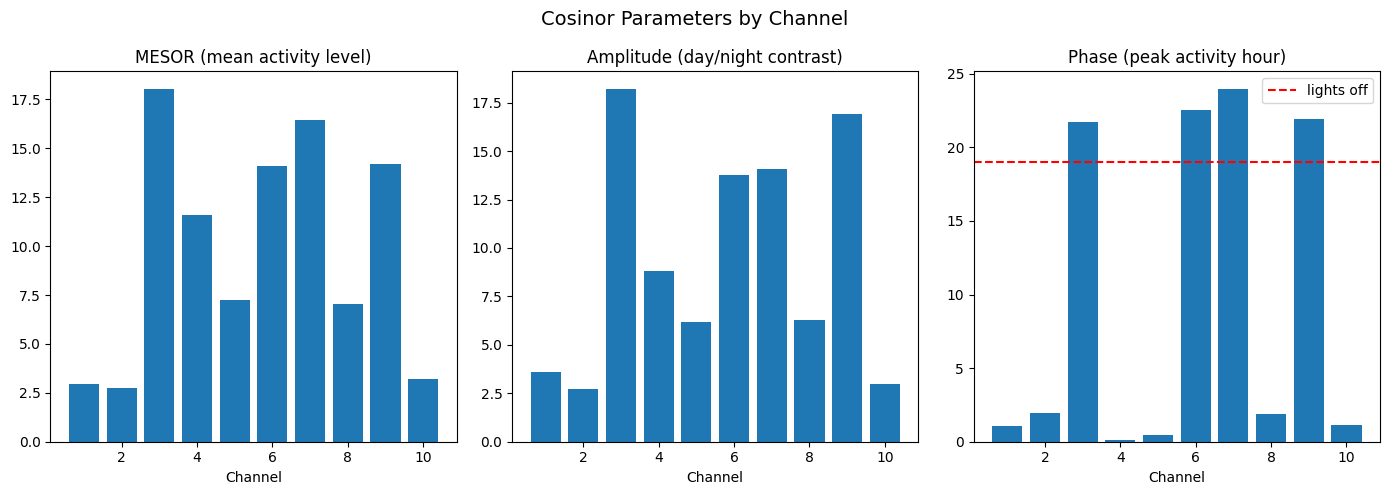

In [13]:
# individual fit plots
# each panel shows observed hourly activity (bars) vs fitted cosine curve (red line)

t_smooth = np.linspace(0, 23, 200)
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=False)
axes = axes.flatten()

for i, ch in enumerate(sorted(df_all['Ch'].unique())):
    t = np.arange(24)
    y = hourly_mean[ch].values
    axes[i].bar(t, y, color='steelblue', alpha=0.5, label='Observed')
    
    if ch in cosinor_df.index:
        params = cosinor_df.loc[ch, ['mesor', 'amplitude', 'phase']].values
        axes[i].plot(t_smooth, cosinor(t_smooth, *params),
                     color='red', linewidth=2, label='Fit')
        axes[i].set_title(f'Ch {ch} | R²={cosinor_df.loc[ch, "r_squared"]:.2f}')
    
    axes[i].set_xticks([0, 6, 12, 18, 23])
    axes[i].set_xlabel('Hour')
    axes[i].set_ylabel('Mean Counts')
    axes[i].legend(fontsize=7)

plt.suptitle('Cosinor Fits per Mouse', fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(cosinor_df.index, cosinor_df['mesor'])
axes[0].set_title('MESOR (mean activity level)')
axes[0].set_xlabel('Channel')

axes[1].bar(cosinor_df.index, cosinor_df['amplitude'])
axes[1].set_title('Amplitude (day/night contrast)')
axes[1].set_xlabel('Channel')

axes[2].bar(cosinor_df.index, cosinor_df['phase'])
axes[2].set_title('Phase (peak activity hour)')
axes[2].set_xlabel('Channel')
axes[2].axhline(y=19, color='red', linestyle='--', label='lights off')  # adjust to schedule
axes[2].legend()

plt.suptitle('Cosinor Parameters by Channel', fontsize=14)
plt.tight_layout()
plt.show()

Linnear Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, classification_report

hourly = df_all.groupby(['Ch', 'Date', 'hour'])['Wheel (counts)'].sum().reset_index() #helps to reduce inflation from zero run intervals

hourly['active'] = (hourly['Wheel (counts)'] > 0).astype(int) # binary outcome --> was the mouse running at all during this hour?

# cyclic encoding of hour 
# converts 0-23 into two features on a circle
# allows for better representation by placing 11pm (23) close to midnight (0) instead of far apart as in linear encoding
hourly['hour_sin'] = np.sin(2 * np.pi * hourly['hour'] / 24)
hourly['hour_cos'] = np.cos(2 * np.pi * hourly['hour'] / 24)



In [15]:
# prepare features and target for modeling
hours = np.arange(0, 24)
X_pred = np.column_stack([
    np.sin(2 * np.pi * hours / 24),
    np.cos(2 * np.pi * hours / 24)
])

In [16]:
logistic_results = []

for ch, df_ch in hourly.groupby('Ch'):
    X = df_ch[['hour_sin', 'hour_cos']].values
    y = df_ch['active'].values
    
    model = LogisticRegression()
    model.fit(X, y)
    
    # predict probability of running at each hour
    probs = model.predict_proba(X_pred)[:, 1]
    y_pred = model.predict(X)
    bal_acc = balanced_accuracy_score(y, y_pred)
    
    logistic_results.append({
        'channel': ch,
        'probs': probs,
        'balanced_accuracy': round(bal_acc, 3),
        'model': model
    })

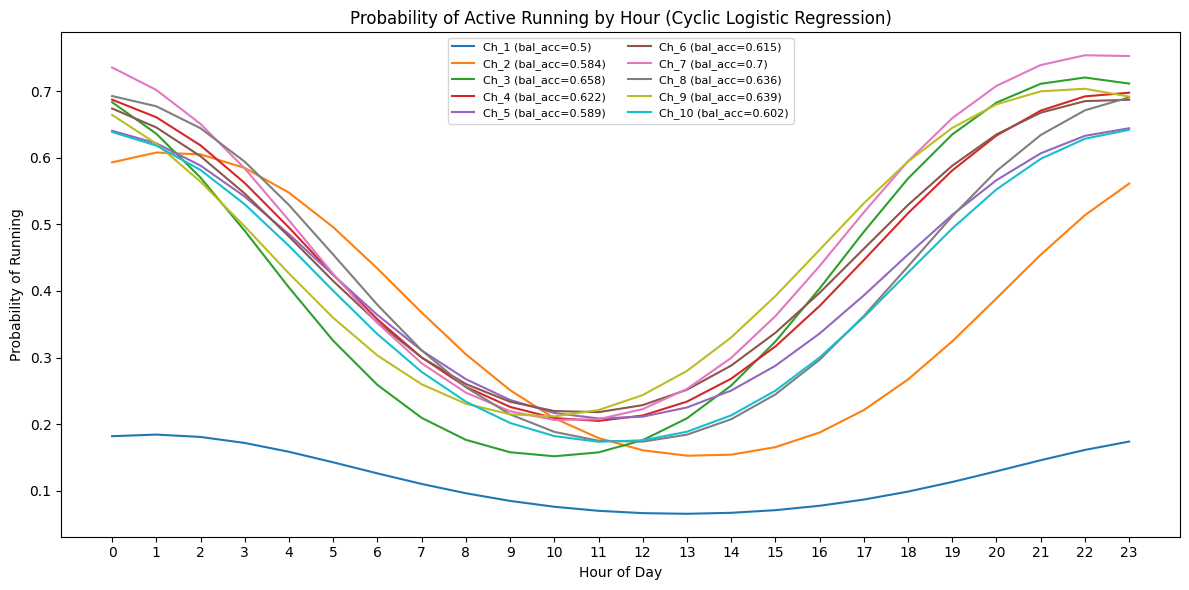

         balanced_accuracy
channel                   
1                    0.500
2                    0.584
3                    0.658
4                    0.622
5                    0.589
6                    0.615
7                    0.700
8                    0.636
9                    0.639
10                   0.602

Channel 1:
              precision    recall  f1-score   support

    inactive       0.88      1.00      0.94      1061
      active       0.00      0.00      0.00       142

    accuracy                           0.88      1203
   macro avg       0.44      0.50      0.47      1203
weighted avg       0.78      0.88      0.83      1203


Channel 2:
              precision    recall  f1-score   support

    inactive       0.69      0.77      0.73       766
      active       0.50      0.40      0.44       437

    accuracy                           0.64      1203
   macro avg       0.59      0.58      0.59      1203
weighted avg       0.62      0.64      0.62      1203

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [17]:
# probability curve plot
# each line shows the predicted probability of that mouse running at each hour
# the height of the peak reflects how strong activity likleyhood

plt.figure(figsize=(12, 6))
for r in logistic_results:
    plt.plot(hours, r['probs'],
             label=f"Ch_{r['channel']} (bal_acc={r['balanced_accuracy']})",
             linewidth=1.5)

plt.xlabel('Hour of Day')
plt.ylabel('Probability of Running')
plt.title('Probability of Active Running by Hour (Cyclic Logistic Regression)')
plt.xticks(range(0, 24))
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

# quick table showing how well hour of day predicts running for each mouse
# higher = hour of day is a stronger predictor of whether that mouse is running

log_summary = pd.DataFrame([{
    'channel': r['channel'],
    'balanced_accuracy': r['balanced_accuracy']
} for r in logistic_results]).set_index('channel')

print(log_summary)

# detailed classification report (optional, shows precision/recall per class)
for r in logistic_results:
    df_ch = hourly[hourly['Ch'] == r['channel']]
    X = df_ch[['hour_sin', 'hour_cos']].values
    y = df_ch['active'].values
    y_pred = r['model'].predict(X)
    
    print(f"\nChannel {r['channel']}:")
    print(classification_report(y, y_pred, target_names=['inactive', 'active']))

PCA

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [19]:
features = []

for ch, df_ch in df_all.groupby('Ch'):
    
    # overall running volume
    total_counts = df_ch['Wheel (counts)'].sum()

    # how nocturnal is this mouse -- adjust hours to match your vivarium schedule
    dark = df_ch[df_ch['hour'].between(19, 23) | df_ch['hour'].between(0, 6)]
    light = df_ch[~(df_ch['hour'].between(19, 23) | df_ch['hour'].between(0, 6))]
    dark_light_ratio = dark['Wheel (counts)'].sum() / (light['Wheel (counts)'].sum() + 1)

    # day-to-day consistency -- high CV means erratic runner
    daily = df_ch.groupby('Date')['Wheel (counts)'].sum()
    cv = daily.std() / (daily.mean() + 1)

    # peak hour from cosinor if available, otherwise raw peak
    if ch in cosinor_df.index:
        peak_hour = cosinor_df.loc[ch, 'phase']
    else:
        peak_hour = df_ch.groupby('hour')['Wheel (counts)'].sum().idxmax()

    # bout detection -- continuous run of non-zero intervals
    intervals = df_ch['Wheel (counts)'].values
    bout_lengths = []
    current = 0
    for val in intervals:
        if val > 0:
            current += 1
        elif current > 0:
            bout_lengths.append(current)
            current = 0
    if current > 0:
        bout_lengths.append(current)

    features.append({
        'channel': ch,
        'total_counts': total_counts,
        'dark_light_ratio': dark_light_ratio,
        'daily_cv': cv,
        'peak_hour': peak_hour,
        'mean_bout_length': np.mean(bout_lengths) if bout_lengths else 0,
        'n_bouts': len(bout_lengths)
    })

feat_df = pd.DataFrame(features).set_index('channel')
print("Feature matrix:")
print(feat_df.round(3))

Feature matrix:
         total_counts  dark_light_ratio  daily_cv  peak_hour  \
channel                                                        
1             42595.0             9.748     1.993      1.088   
2             39263.0             7.810     1.490      1.922   
3            259724.0             2.723     0.613     21.724   
4            167233.0             3.948     0.558      0.086   
5            104239.0             3.803     0.493      0.469   
6            202992.0             2.939     0.639     22.528   
7            237086.0             3.869     0.550     23.964   
8            101314.0             5.087     0.518      1.858   
9            204793.0             3.752     0.735     21.892   
10            45886.0             4.324     0.564      1.104   

         mean_bout_length  n_bouts  
channel                             
1                   2.513      191  
2                   1.880      625  
3                   3.268      680  
4                   2.545     

In [20]:
# standardize features befor PCA
scaler = StandardScaler()
feat_scaled = scaler.fit_transform(feat_df)

# perform PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(feat_scaled)

print(f"\nVariance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance retained:   {sum(pca.explained_variance_ratio_):.1%}")


Variance explained by PC1: 68.2%
Variance explained by PC2: 23.3%
Total variance retained:   91.5%


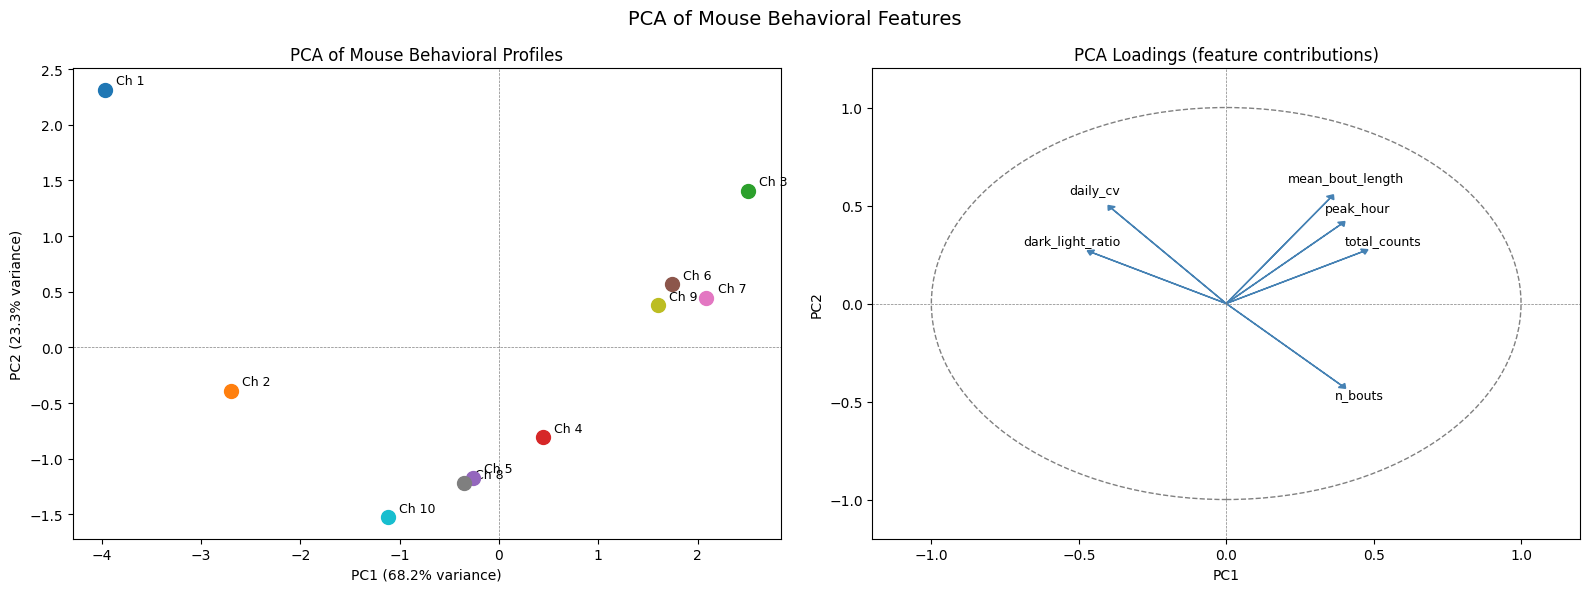

In [21]:
# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]


for i, ch in enumerate(feat_df.index):
    ax.scatter(pca_coords[i, 0], pca_coords[i, 1], s=100, zorder=5)
    ax.annotate(f'Ch {ch}',
                (pca_coords[i, 0], pca_coords[i, 1]),
                textcoords='offset points',
                xytext=(8, 4),
                fontsize=9)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA of Mouse Behavioral Profiles')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax2 = axes[1]
feature_names = feat_df.columns
loadings = pca.components_.T

for i, name in enumerate(feature_names):
    ax2.arrow(0, 0, loadings[i, 0], loadings[i, 1],
              head_width=0.03, head_length=0.02, fc='steelblue', ec='steelblue')
    ax2.text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15, name, fontsize=9, ha='center')

ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('PCA Loadings (feature contributions)')
ax2.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax2.axvline(0, color='grey', linewidth=0.5, linestyle='--')
circle = plt.Circle((0, 0), 1, fill=False, color='grey', linestyle='--')
ax2.add_patch(circle)

plt.suptitle('PCA of Mouse Behavioral Features', fontsize=14)
plt.tight_layout()
plt.show()

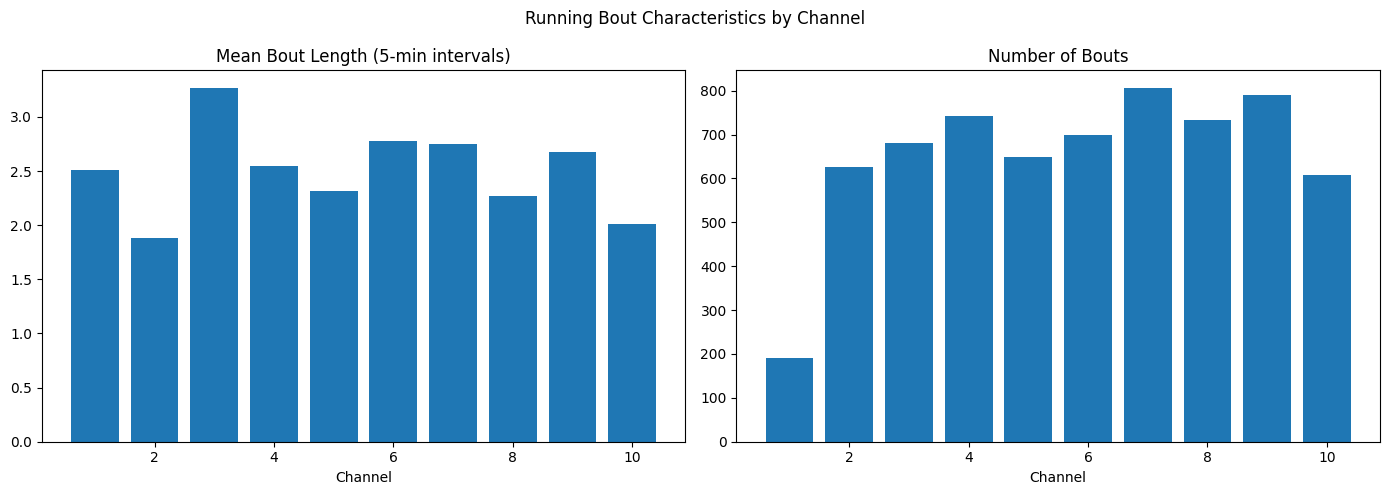

In [22]:
# mean bout length vs n_bouts scatter, labeled by channel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(feat_df.index, feat_df['mean_bout_length'])
axes[0].set_title('Mean Bout Length (5-min intervals)')
axes[0].set_xlabel('Channel')

axes[1].bar(feat_df.index, feat_df['n_bouts'])
axes[1].set_title('Number of Bouts')
axes[1].set_xlabel('Channel')

plt.suptitle('Running Bout Characteristics by Channel')
plt.tight_layout()
plt.show()

Re-Run Models with Sectioned Data by Date

In [23]:
df_early = df_all[df_all['Date'] < pd.to_datetime('2022-01-14').date()]
df_late = df_all[df_all['Date'] >= pd.to_datetime('2022-01-14').date()]

zero_days = pv_daily[pv_daily.sum(axis=1) == 0].index
df_clean = df_all[~df_all['Date'].isin(zero_days)]

=== Original (with zero days) ===
          mesor  amplitude   phase  r_squared
channel                                      
1         2.958      3.602   1.088      0.554
2         2.727      2.735   1.922      0.353
3        18.037     18.208  21.724      0.567
4        11.616      8.832   0.086      0.216
5         7.239      6.205   0.469      0.232
6        14.098     13.773  22.528      0.425
7        16.468     14.090  23.964      0.304
8         7.037      6.274   1.858      0.281
9        14.223     16.940  21.892      0.683
10        3.187      2.971   1.104      0.237

=== Clean (zero days removed) ===
          mesor  amplitude   phase  r_squared
channel                                      
1         3.120      3.798   1.127      0.556
2         2.876      2.895   1.979      0.354
3        18.930     19.017  21.773      0.565
4        12.231      9.325   0.167      0.215
5         7.630      6.575   0.536      0.232
6        14.813     14.430  22.583      0.423
7        17

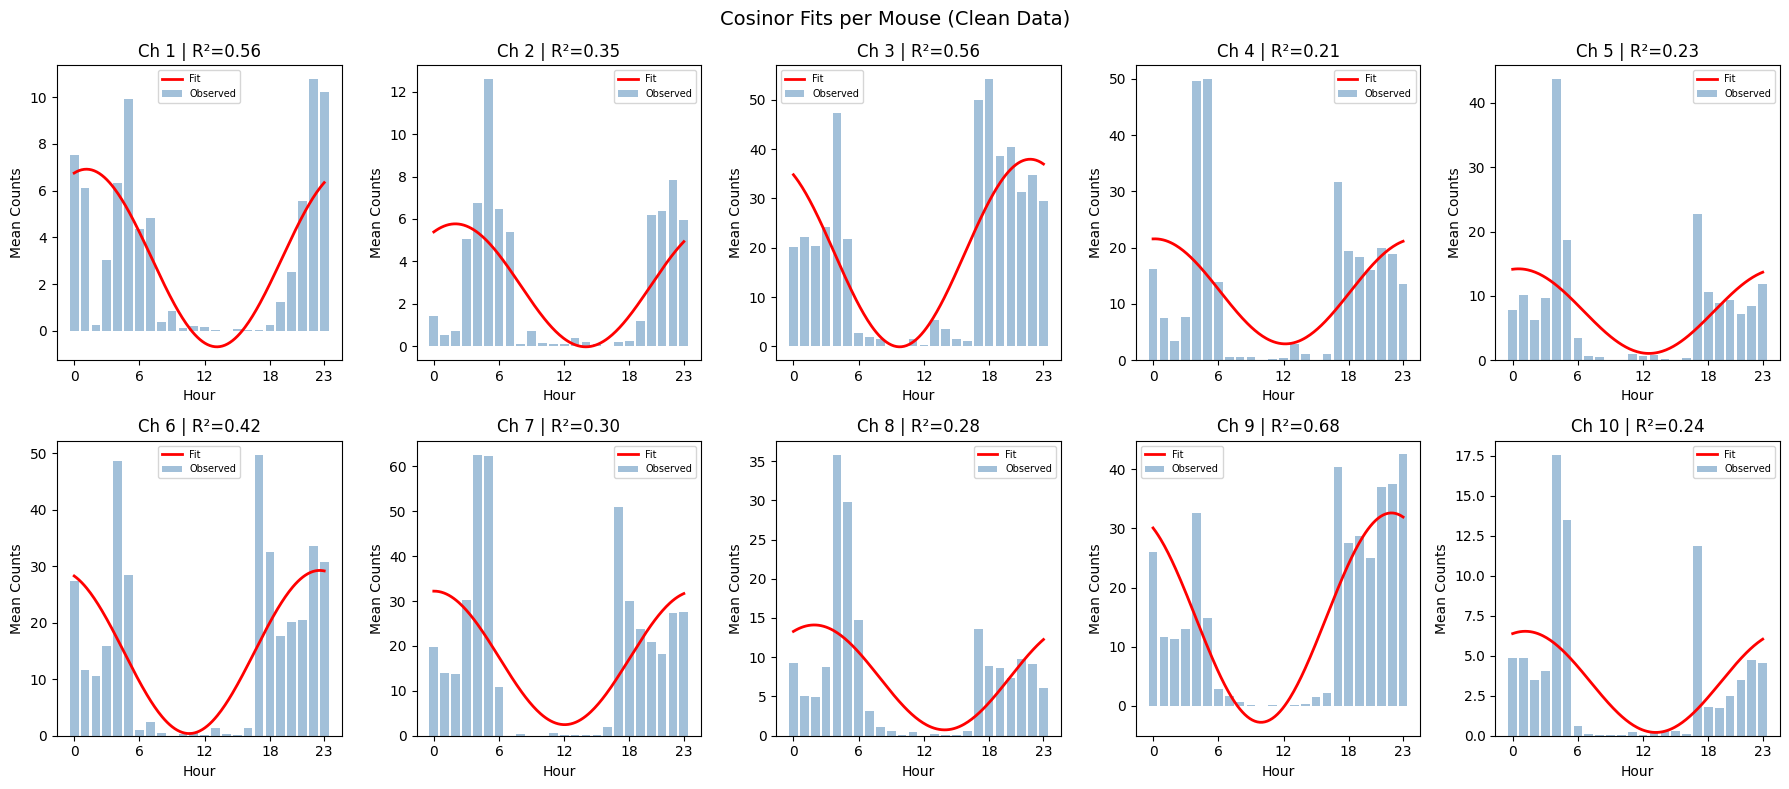

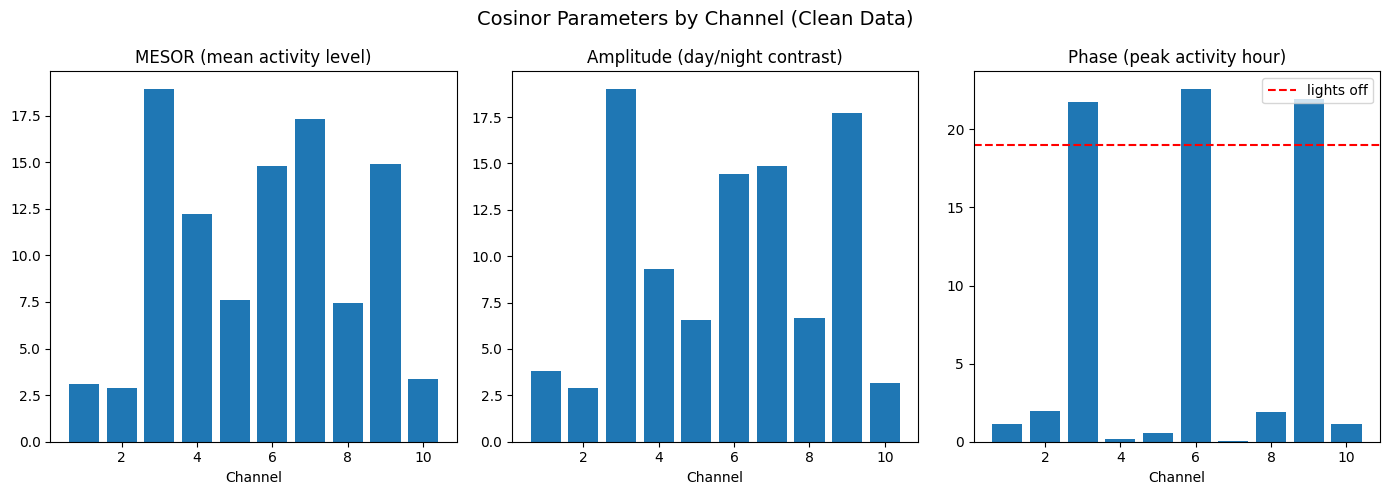

In [24]:
from scipy.optimize import curve_fit

# rerun cosinor on cleaned data with artifact days removed
# compare these results to the original cosinor_df to see how much the zero days affected the fit

hourly_mean_clean = df_clean.groupby(['Ch', 'hour'])['Wheel (counts)'].mean()

def cosinor(t, mesor, amplitude, phase):
    return mesor + amplitude * np.cos(2 * np.pi / 24 * (t - phase))

cosinor_results_clean = []

for ch in sorted(df_clean['Ch'].unique()):
    t = np.arange(24)
    y = hourly_mean_clean.loc[ch].values

    p0 = [y.mean(), (y.max() - y.min()) / 2, t[np.argmax(y)]]

    try:
        params, _ = curve_fit(cosinor, t, y, p0=p0, maxfev=5000)
        mesor, amplitude, phase = params
        phase = phase % 24

        y_pred = cosinor(t, *params)
        r_squared = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)

        cosinor_results_clean.append({
            'channel': ch,
            'mesor': round(mesor, 3),
            'amplitude': round(amplitude, 3),
            'phase': round(phase, 3),
            'r_squared': round(r_squared, 3)
        })

    except RuntimeError:
        print(f'Channel {ch}: cosinor fit did not converge')

cosinor_df_clean = pd.DataFrame(cosinor_results_clean).set_index('channel')

# print side by side comparison with original
print('=== Original (with zero days) ===')
print(cosinor_df)
print('\n=== Clean (zero days removed) ===')
print(cosinor_df_clean)
print('\n=== R² change ===')
print((cosinor_df_clean['r_squared'] - cosinor_df['r_squared']).round(3))

# individual fit plots
t_smooth = np.linspace(0, 23, 200)
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=False)
axes = axes.flatten()

for i, ch in enumerate(sorted(df_clean['Ch'].unique())):
    t = np.arange(24)
    y = hourly_mean_clean.loc[ch].values
    axes[i].bar(t, y, color='steelblue', alpha=0.5, label='Observed')

    if ch in cosinor_df_clean.index:
        params = cosinor_df_clean.loc[ch, ['mesor', 'amplitude', 'phase']].values
        axes[i].plot(t_smooth, cosinor(t_smooth, *params),
                     color='red', linewidth=2, label='Fit')
        axes[i].set_title(f'Ch {ch} | R²={cosinor_df_clean.loc[ch, "r_squared"]:.2f}')

    axes[i].set_xticks([0, 6, 12, 18, 23])
    axes[i].set_xlabel('Hour')
    axes[i].set_ylabel('Mean Counts')
    axes[i].legend(fontsize=7)

plt.suptitle('Cosinor Fits per Mouse (Clean Data)', fontsize=14)
plt.tight_layout()
plt.show()

# parameter comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(cosinor_df_clean.index, cosinor_df_clean['mesor'])
axes[0].set_title('MESOR (mean activity level)')
axes[0].set_xlabel('Channel')

axes[1].bar(cosinor_df_clean.index, cosinor_df_clean['amplitude'])
axes[1].set_title('Amplitude (day/night contrast)')
axes[1].set_xlabel('Channel')

axes[2].bar(cosinor_df_clean.index, cosinor_df_clean['phase'])
axes[2].set_title('Phase (peak activity hour)')
axes[2].set_xlabel('Channel')
axes[2].axhline(y=19, color='red', linestyle='--', label='lights off')
axes[2].legend()

plt.suptitle('Cosinor Parameters by Channel (Clean Data)', fontsize=14)
plt.tight_layout()
plt.show()

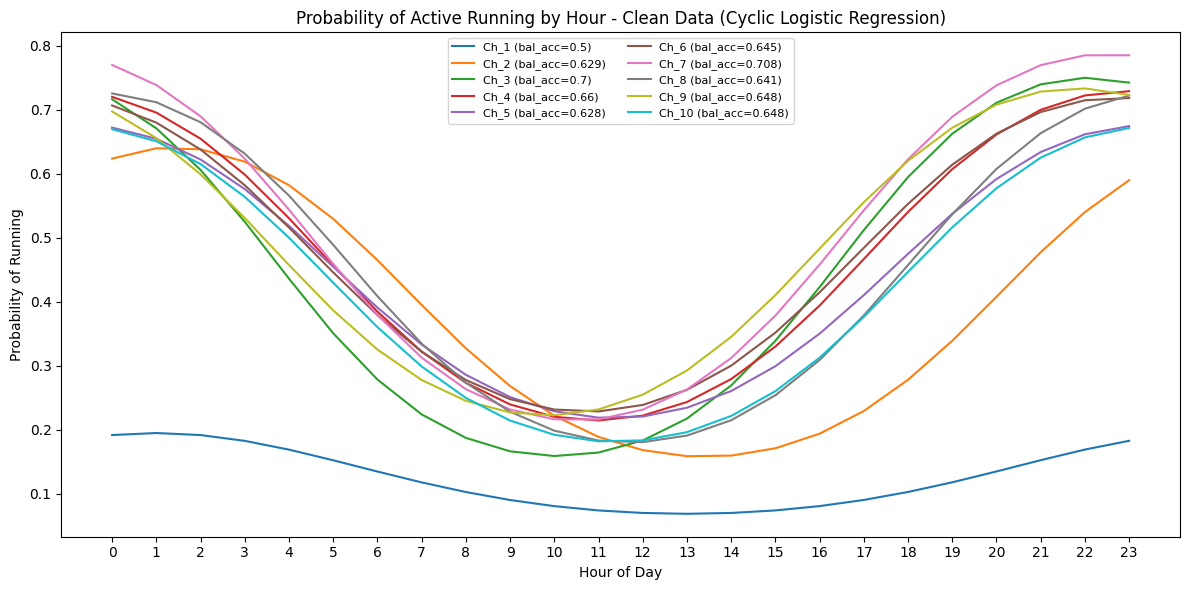

         bal_acc_original  bal_acc_clean  change
channel                                         
1                   0.500          0.500   0.000
2                   0.584          0.629   0.045
3                   0.658          0.700   0.042
4                   0.622          0.660   0.038
5                   0.589          0.628   0.039
6                   0.615          0.645   0.030
7                   0.700          0.708   0.008
8                   0.636          0.641   0.005
9                   0.639          0.648   0.009
10                  0.602          0.648   0.046


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, classification_report

# rerun logistic regression on cleaned data
# artifact zero days would have added hours where no mouse could ever be active
# which artificially inflated the inactive class -- removing them gives a fairer model

hourly_clean = df_clean.groupby(['Ch', 'Date', 'hour'])['Wheel (counts)'].sum().reset_index()
hourly_clean['active'] = (hourly_clean['Wheel (counts)'] > 0).astype(int)
hourly_clean['hour_sin'] = np.sin(2 * np.pi * hourly_clean['hour'] / 24)
hourly_clean['hour_cos'] = np.cos(2 * np.pi * hourly_clean['hour'] / 24)

hours = np.arange(0, 24)
X_pred = np.column_stack([
    np.sin(2 * np.pi * hours / 24),
    np.cos(2 * np.pi * hours / 24)
])

logistic_results_clean = []

for ch, df_ch in hourly_clean.groupby('Ch'):
    X = df_ch[['hour_sin', 'hour_cos']].values
    y = df_ch['active'].values

    model = LogisticRegression()
    model.fit(X, y)

    probs = model.predict_proba(X_pred)[:, 1]
    y_pred = model.predict(X)
    bal_acc = balanced_accuracy_score(y, y_pred)

    logistic_results_clean.append({
        'channel': ch,
        'probs': probs,
        'balanced_accuracy': round(bal_acc, 3),
        'model': model
    })

# probability curve plot
plt.figure(figsize=(12, 6))
for r in logistic_results_clean:
    plt.plot(hours, r['probs'],
             label=f"Ch_{r['channel']} (bal_acc={r['balanced_accuracy']})",
             linewidth=1.5)

plt.xlabel('Hour of Day')
plt.ylabel('Probability of Running')
plt.title('Probability of Active Running by Hour - Clean Data (Cyclic Logistic Regression)')
plt.xticks(range(0, 24))
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

# side by side balanced accuracy comparison
log_summary_clean = pd.DataFrame([{
    'channel': r['channel'],
    'bal_acc_clean': r['balanced_accuracy']
} for r in logistic_results_clean]).set_index('channel')

log_summary_original = pd.DataFrame([{
    'channel': r['channel'],
    'bal_acc_original': r['balanced_accuracy']
} for r in logistic_results]).set_index('channel')

comparison = log_summary_original.join(log_summary_clean)
comparison['change'] = (comparison['bal_acc_clean'] - comparison['bal_acc_original']).round(3)
print(comparison)

=== Original feature matrix ===
         total_counts  dark_light_ratio  daily_cv  peak_hour  \
channel                                                        
1             42595.0             9.748     1.993      1.088   
2             39263.0             7.810     1.490      1.922   
3            259724.0             2.723     0.613     21.724   
4            167233.0             3.948     0.558      0.086   
5            104239.0             3.803     0.493      0.469   
6            202992.0             2.939     0.639     22.528   
7            237086.0             3.869     0.550     23.964   
8            101314.0             5.087     0.518      1.858   
9            204793.0             3.752     0.735     21.892   
10            45886.0             4.324     0.564      1.104   

         mean_bout_length  n_bouts  
channel                             
1                   2.513      191  
2                   1.880      625  
3                   3.268      680  
4             

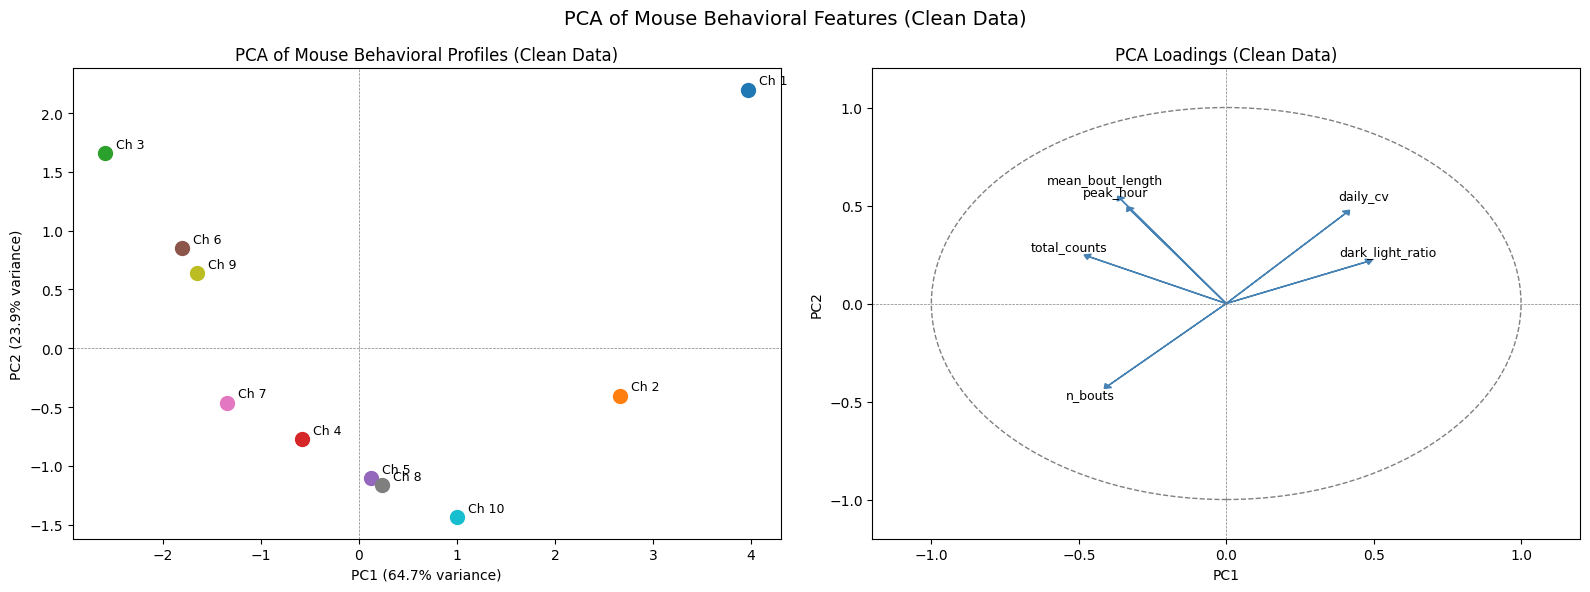

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# rerun PCA feature matrix on cleaned data
# zero artifact days would have deflated daily_cv and dark_light_ratio
# since those days contribute zeros evenly across all hours

features_clean = []

for ch, df_ch in df_clean.groupby('Ch'):

    total_counts = df_ch['Wheel (counts)'].sum()

    dark = df_ch[df_ch['hour'].between(19, 23) | df_ch['hour'].between(0, 6)]
    light = df_ch[~(df_ch['hour'].between(19, 23) | df_ch['hour'].between(0, 6))]
    dark_light_ratio = dark['Wheel (counts)'].sum() / (light['Wheel (counts)'].sum() + 1)

    daily = df_ch.groupby('Date')['Wheel (counts)'].sum()
    cv = daily.std() / (daily.mean() + 1)

    if ch in cosinor_df_clean.index:
        peak_hour = cosinor_df_clean.loc[ch, 'phase']
    else:
        peak_hour = df_ch.groupby('hour')['Wheel (counts)'].sum().idxmax()

    intervals = df_ch['Wheel (counts)'].values
    bout_lengths = []
    current = 0
    for val in intervals:
        if val > 0:
            current += 1
        elif current > 0:
            bout_lengths.append(current)
            current = 0
    if current > 0:
        bout_lengths.append(current)

    features_clean.append({
        'channel': ch,
        'total_counts': total_counts,
        'dark_light_ratio': dark_light_ratio,
        'daily_cv': cv,
        'peak_hour': peak_hour,
        'mean_bout_length': np.mean(bout_lengths) if bout_lengths else 0,
        'n_bouts': len(bout_lengths)
    })

feat_df_clean = pd.DataFrame(features_clean).set_index('channel')

print('=== Original feature matrix ===')
print(feat_df.round(3))
print('\n=== Clean feature matrix ===')
print(feat_df_clean.round(3))

# normalize and run PCA
scaler = StandardScaler()
feat_scaled_clean = scaler.fit_transform(feat_df_clean)

pca_clean = PCA(n_components=2)
pca_coords_clean = pca_clean.fit_transform(feat_scaled_clean)

print(f'\nVariance explained by PC1: {pca_clean.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca_clean.explained_variance_ratio_[1]:.1%}')
print(f'Total variance retained:   {sum(pca_clean.explained_variance_ratio_):.1%}')

# scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]

for i, ch in enumerate(feat_df_clean.index):
    ax.scatter(pca_coords_clean[i, 0], pca_coords_clean[i, 1], s=100, zorder=5)
    ax.annotate(f'Ch {ch}',
                (pca_coords_clean[i, 0], pca_coords_clean[i, 1]),
                textcoords='offset points',
                xytext=(8, 4),
                fontsize=9)

ax.set_xlabel(f'PC1 ({pca_clean.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_clean.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA of Mouse Behavioral Profiles (Clean Data)')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax2 = axes[1]
feature_names = feat_df_clean.columns
loadings = pca_clean.components_.T

for i, name in enumerate(feature_names):
    ax2.arrow(0, 0, loadings[i, 0], loadings[i, 1],
              head_width=0.03, head_length=0.02, fc='steelblue', ec='steelblue')
    ax2.text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15,
             name, fontsize=9, ha='center')

ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('PCA Loadings (Clean Data)')
ax2.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax2.axvline(0, color='grey', linewidth=0.5, linestyle='--')
circle = plt.Circle((0, 0), 1, fill=False, color='grey', linestyle='--')
ax2.add_patch(circle)

plt.suptitle('PCA of Mouse Behavioral Features (Clean Data)', fontsize=14)
plt.tight_layout()
plt.show()

Actogram (visualize activity pattern across study)

In [ ]:
def plot_actogram(df_ch, ch, lights_off=19, lights_on=7):
    # aggregate to hourly resolution for cleaner visualization
    daily_hourly = df_ch.groupby(
        ['Date', 'hour'])['Wheel (counts)'].sum().unstack(fill_value=0)
    dates = sorted(daily_hourly.index)

    fig, ax = plt.subplots(figsize=(12, len(dates) * 0.35 + 2))

    for i, date in enumerate(dates):
        counts = daily_hourly.loc[date].values
        max_val = counts.max()
        if max_val > 0:
            counts_norm = counts / max_val * 0.85  # normalize to row height
        else:
            counts_norm = counts

        for h, val in enumerate(counts_norm):
            if val > 0:
                ax.bar(h + 0.5, val, bottom=i, width=1,
                       color='black', linewidth=0, alpha=0.85)

    # shade dark phase
    ax.axvspan(lights_off, 24, alpha=0.12, color='navy', label=f'Dark phase ({lights_off}:00-{lights_on}:00)')
    ax.axvspan(0, lights_on, alpha=0.12, color='navy')

    # horizontal line between days
    for i in range(len(dates)):
        ax.axhline(i, color='lightgrey', linewidth=0.3)

    ax.set_yticks(range(len(dates)))
    ax.set_yticklabels([str(d) for d in dates], fontsize=7)
    ax.set_xticks(range(0, 25, 2))
    ax.set_xlim(0, 24)
    ax.set_xlabel('Hour of Day')
    ax.set_title(f'Actogram — Channel {ch}', fontsize=13)
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

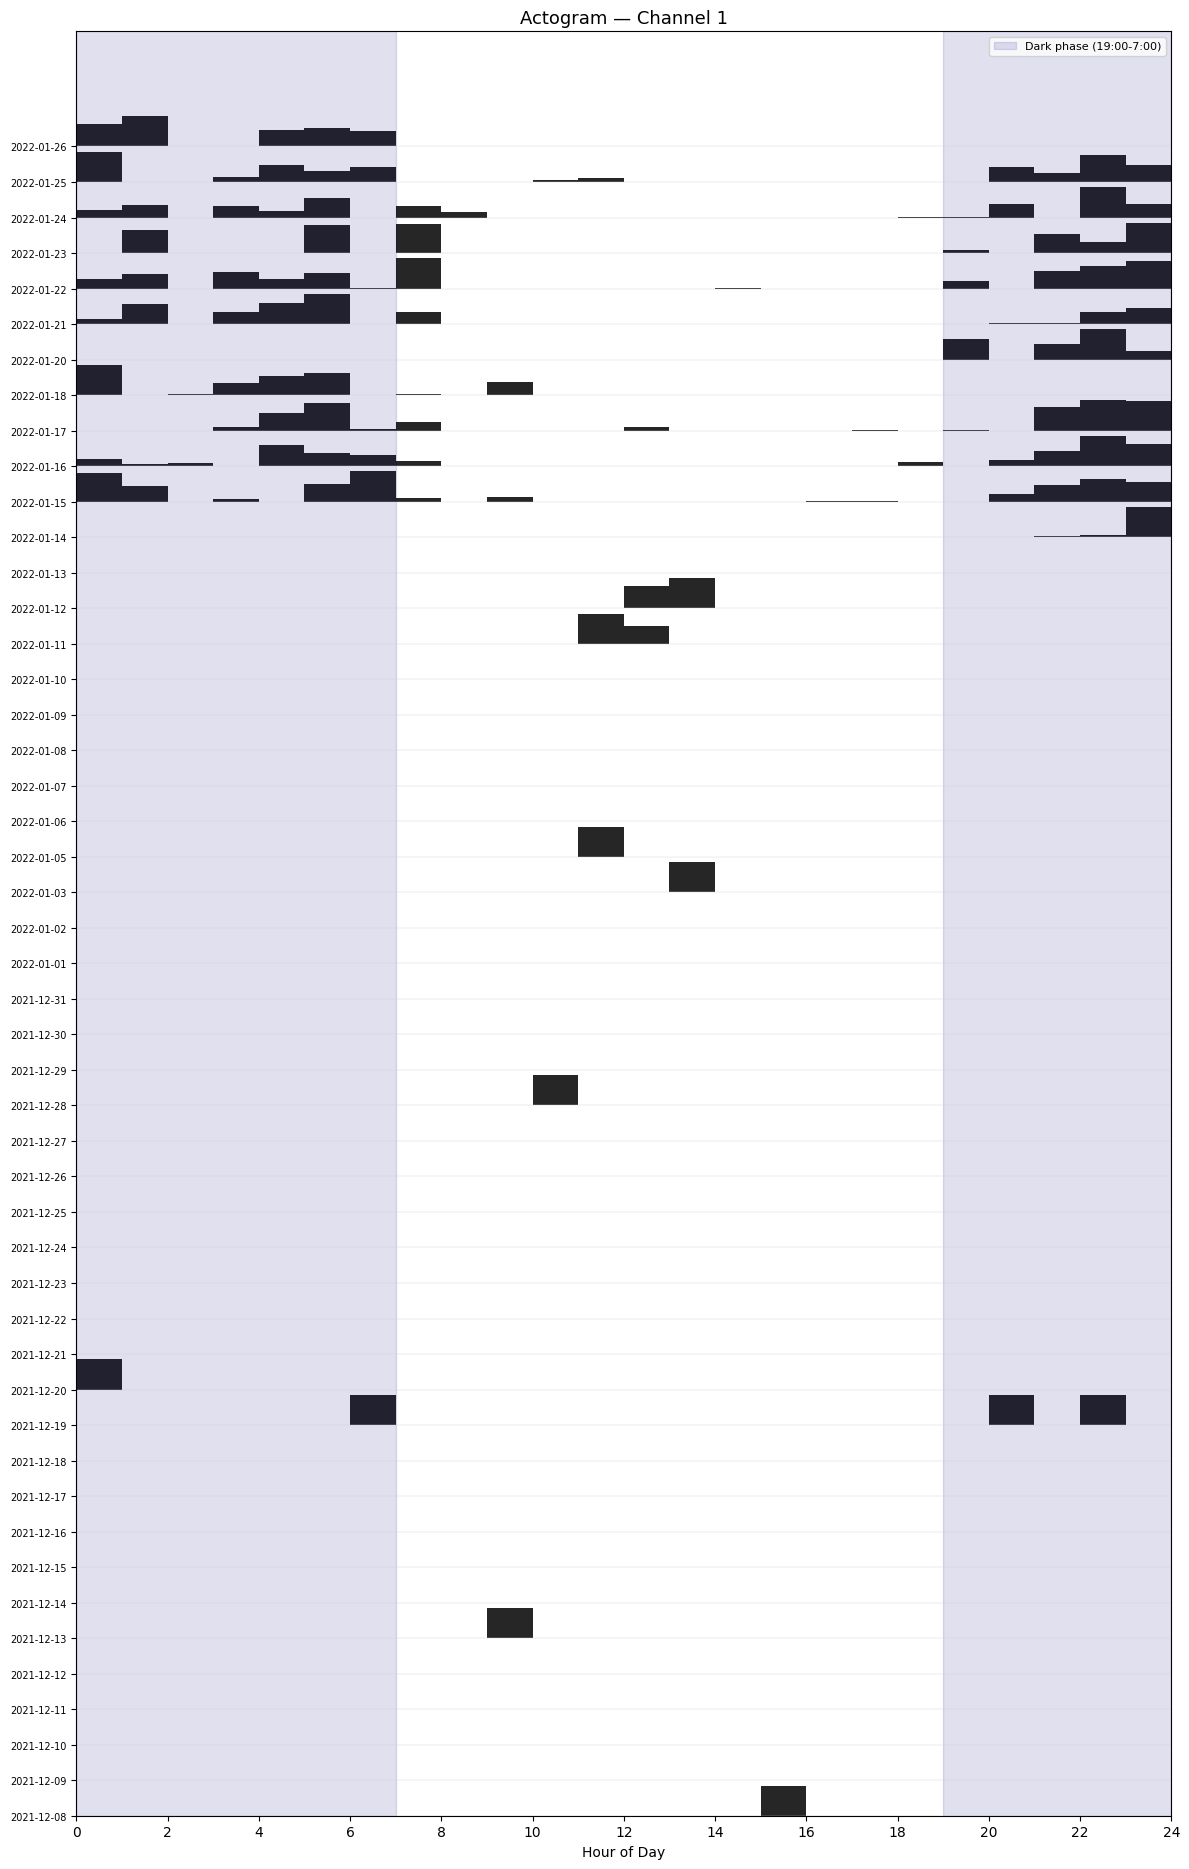

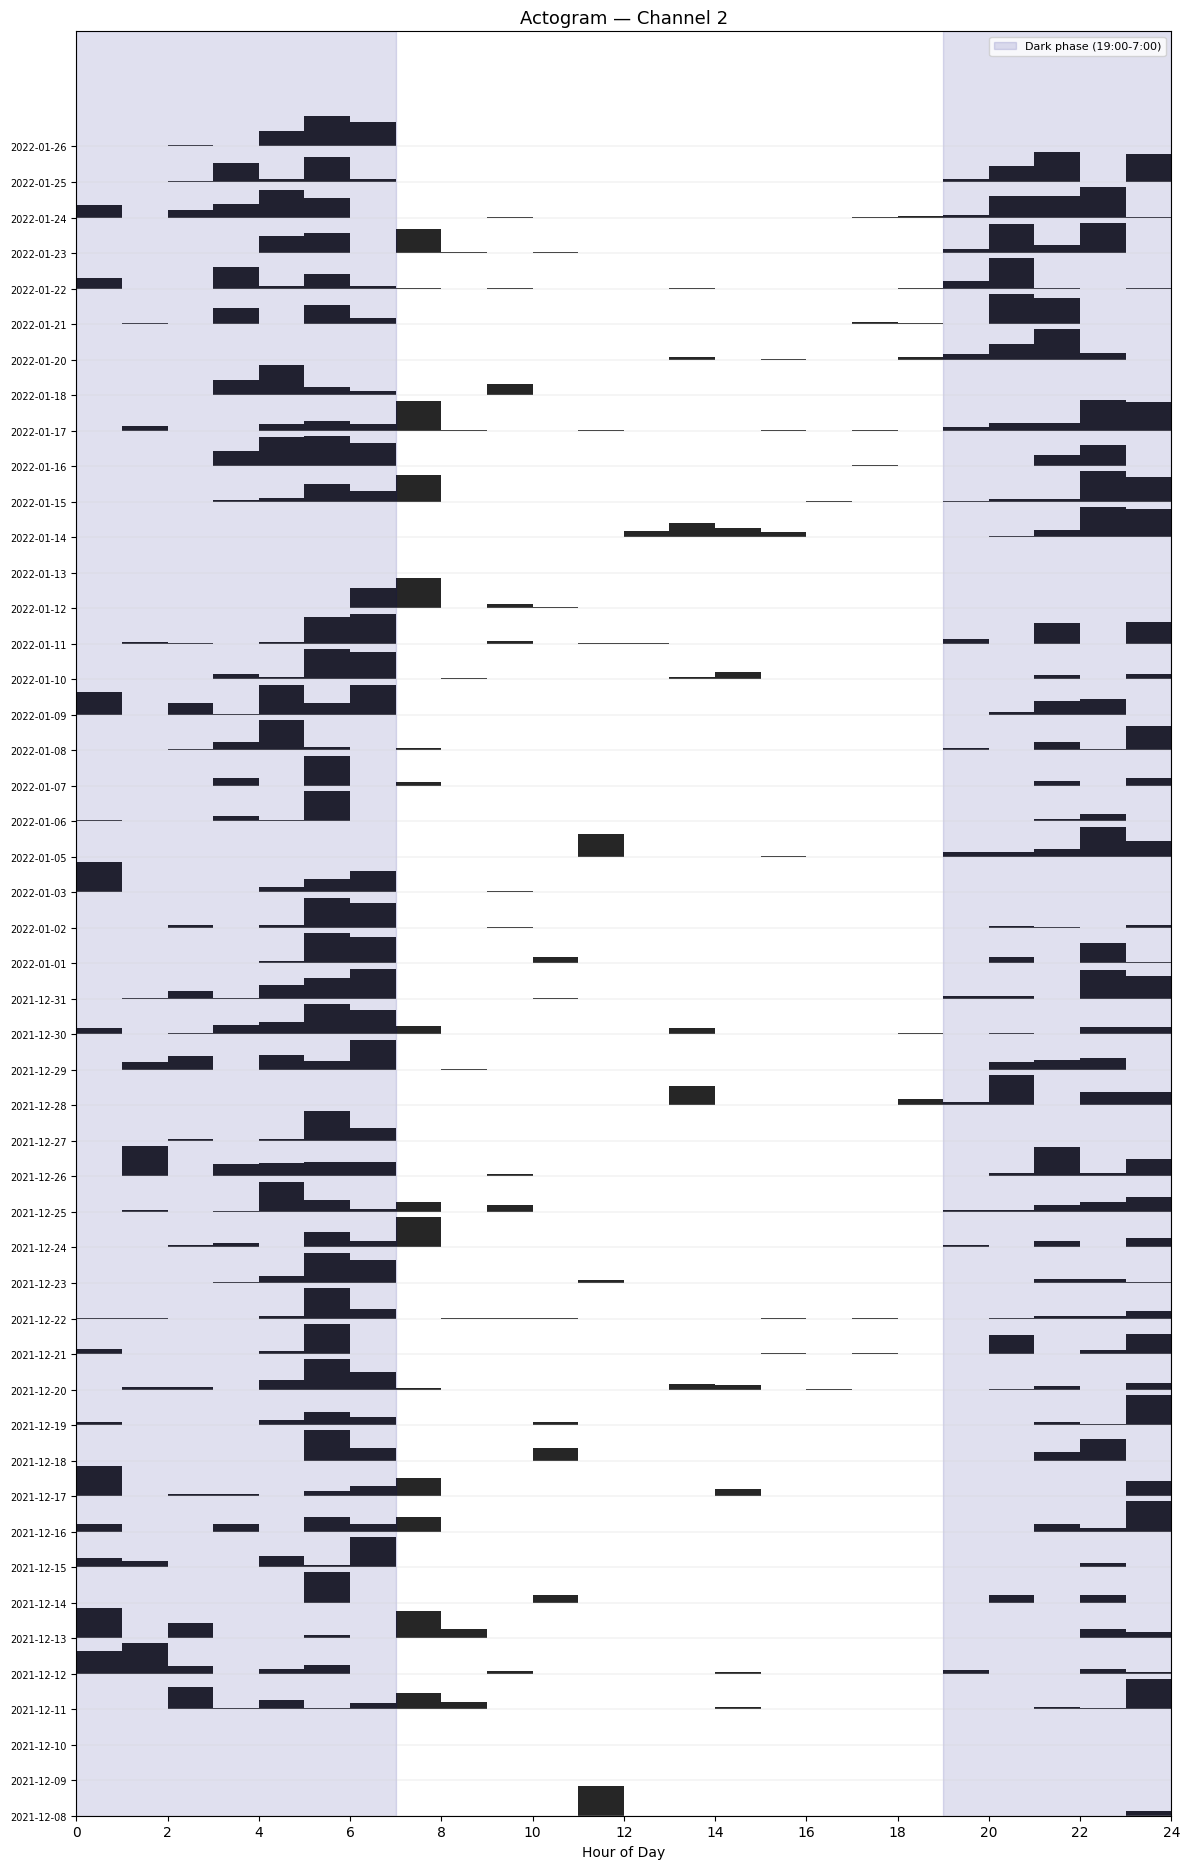

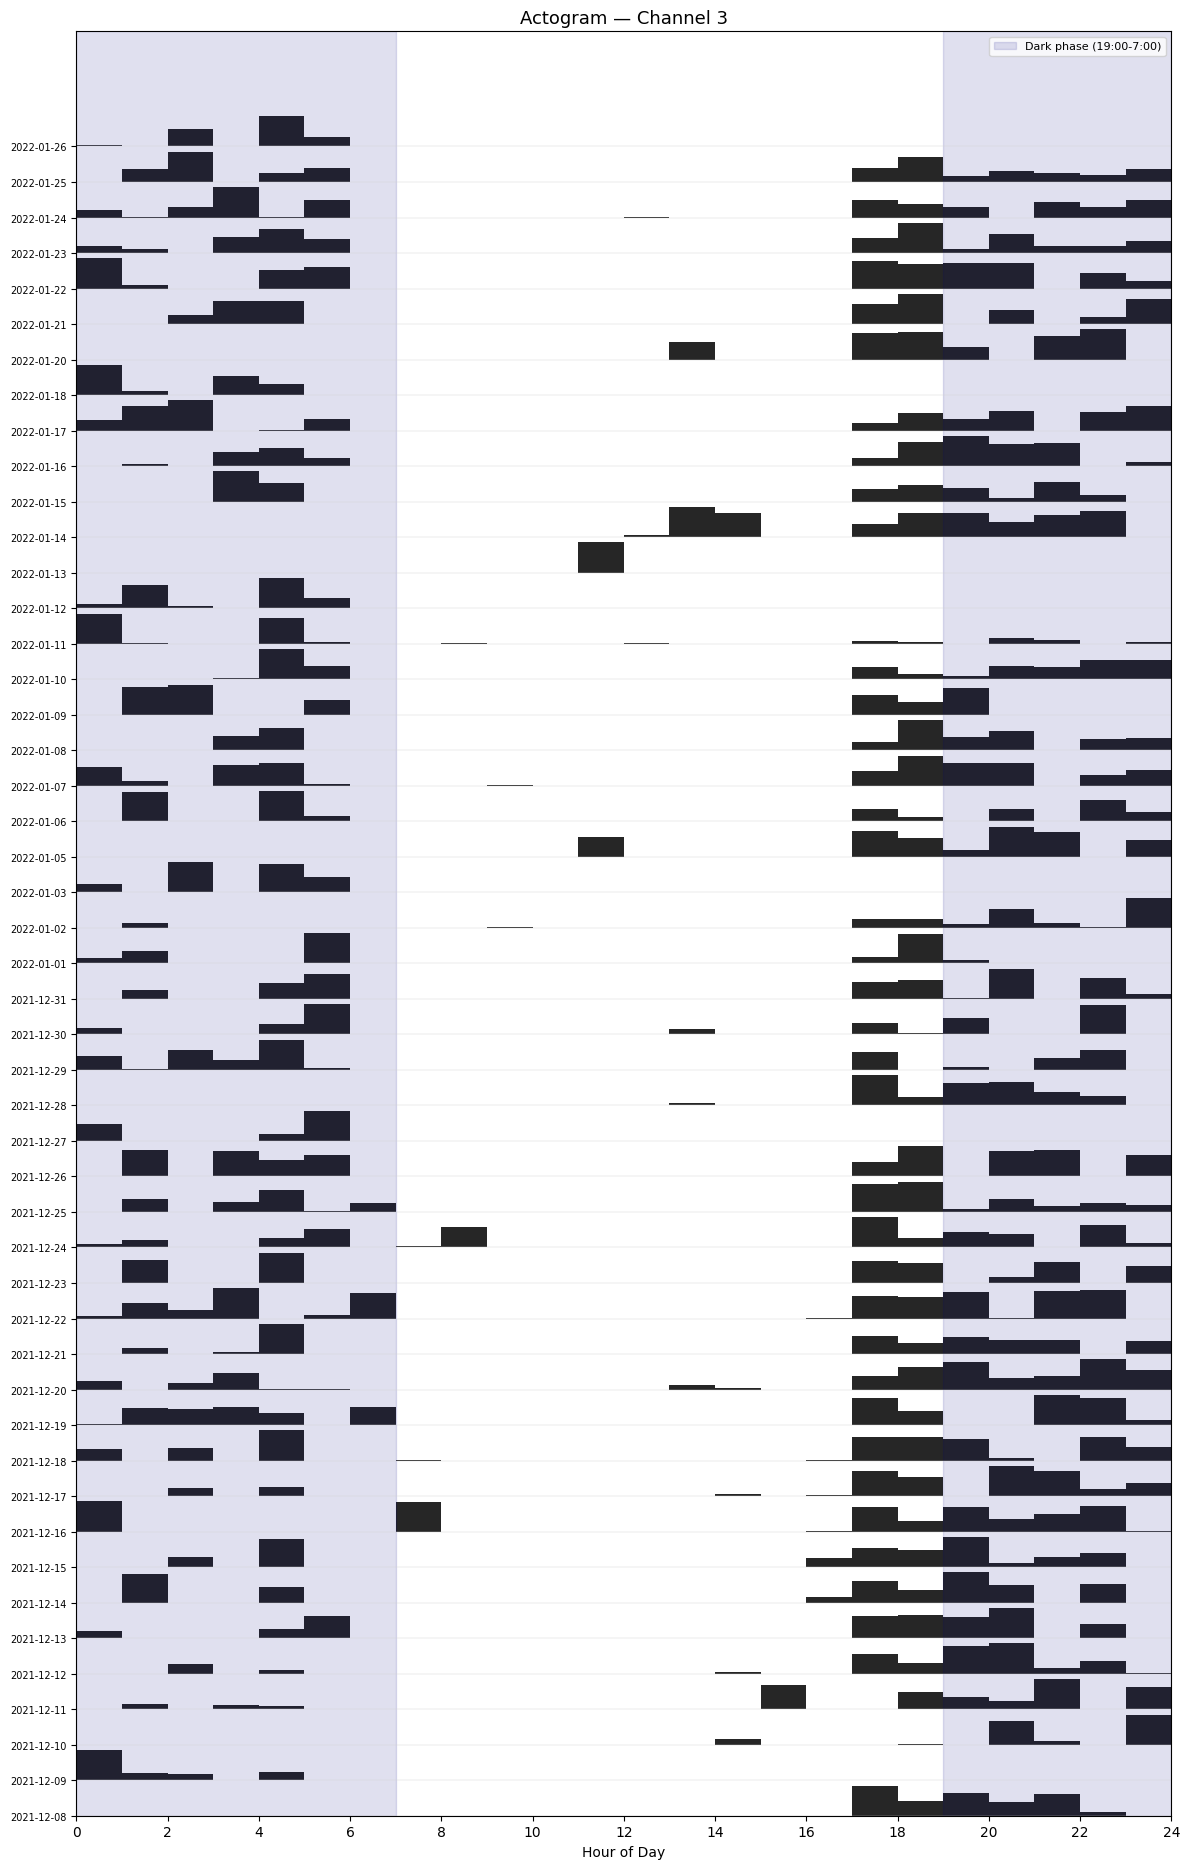

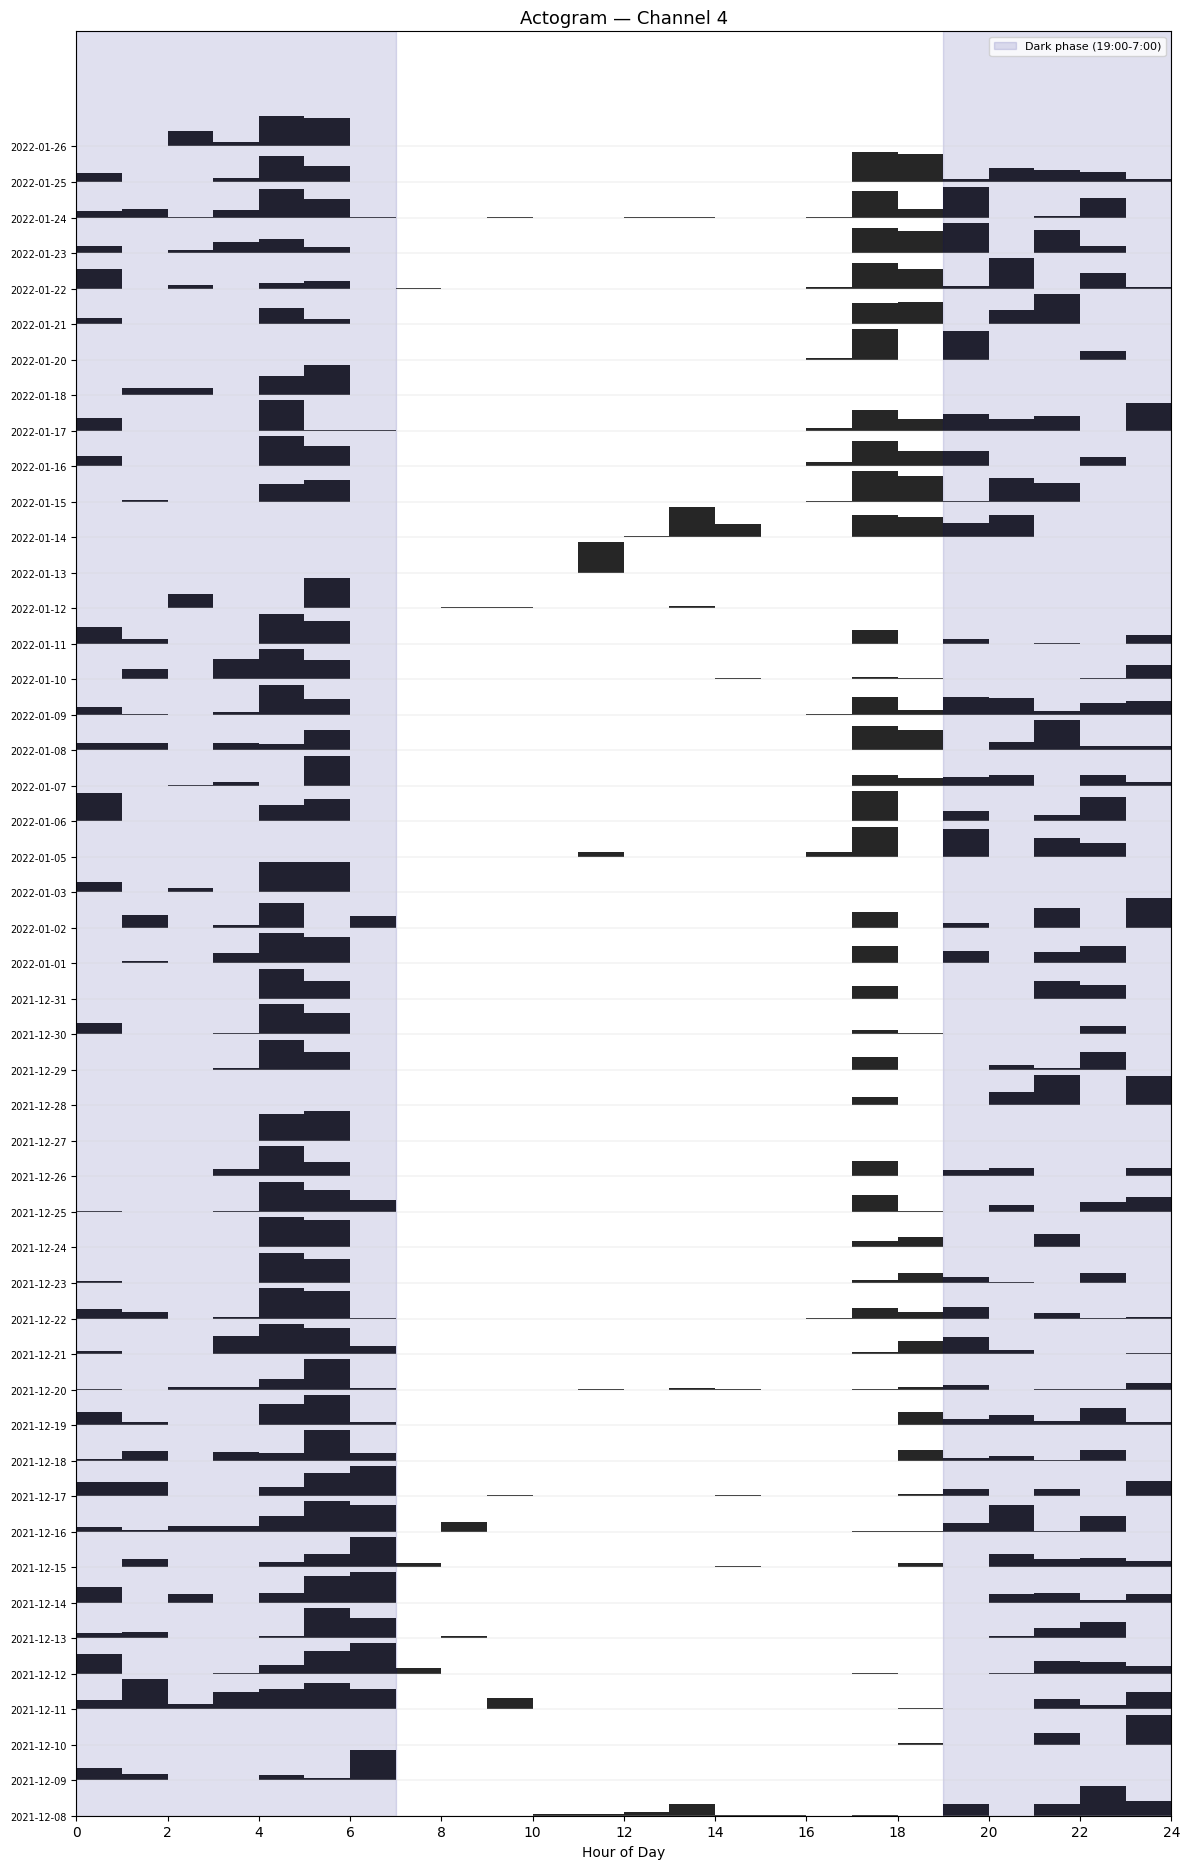

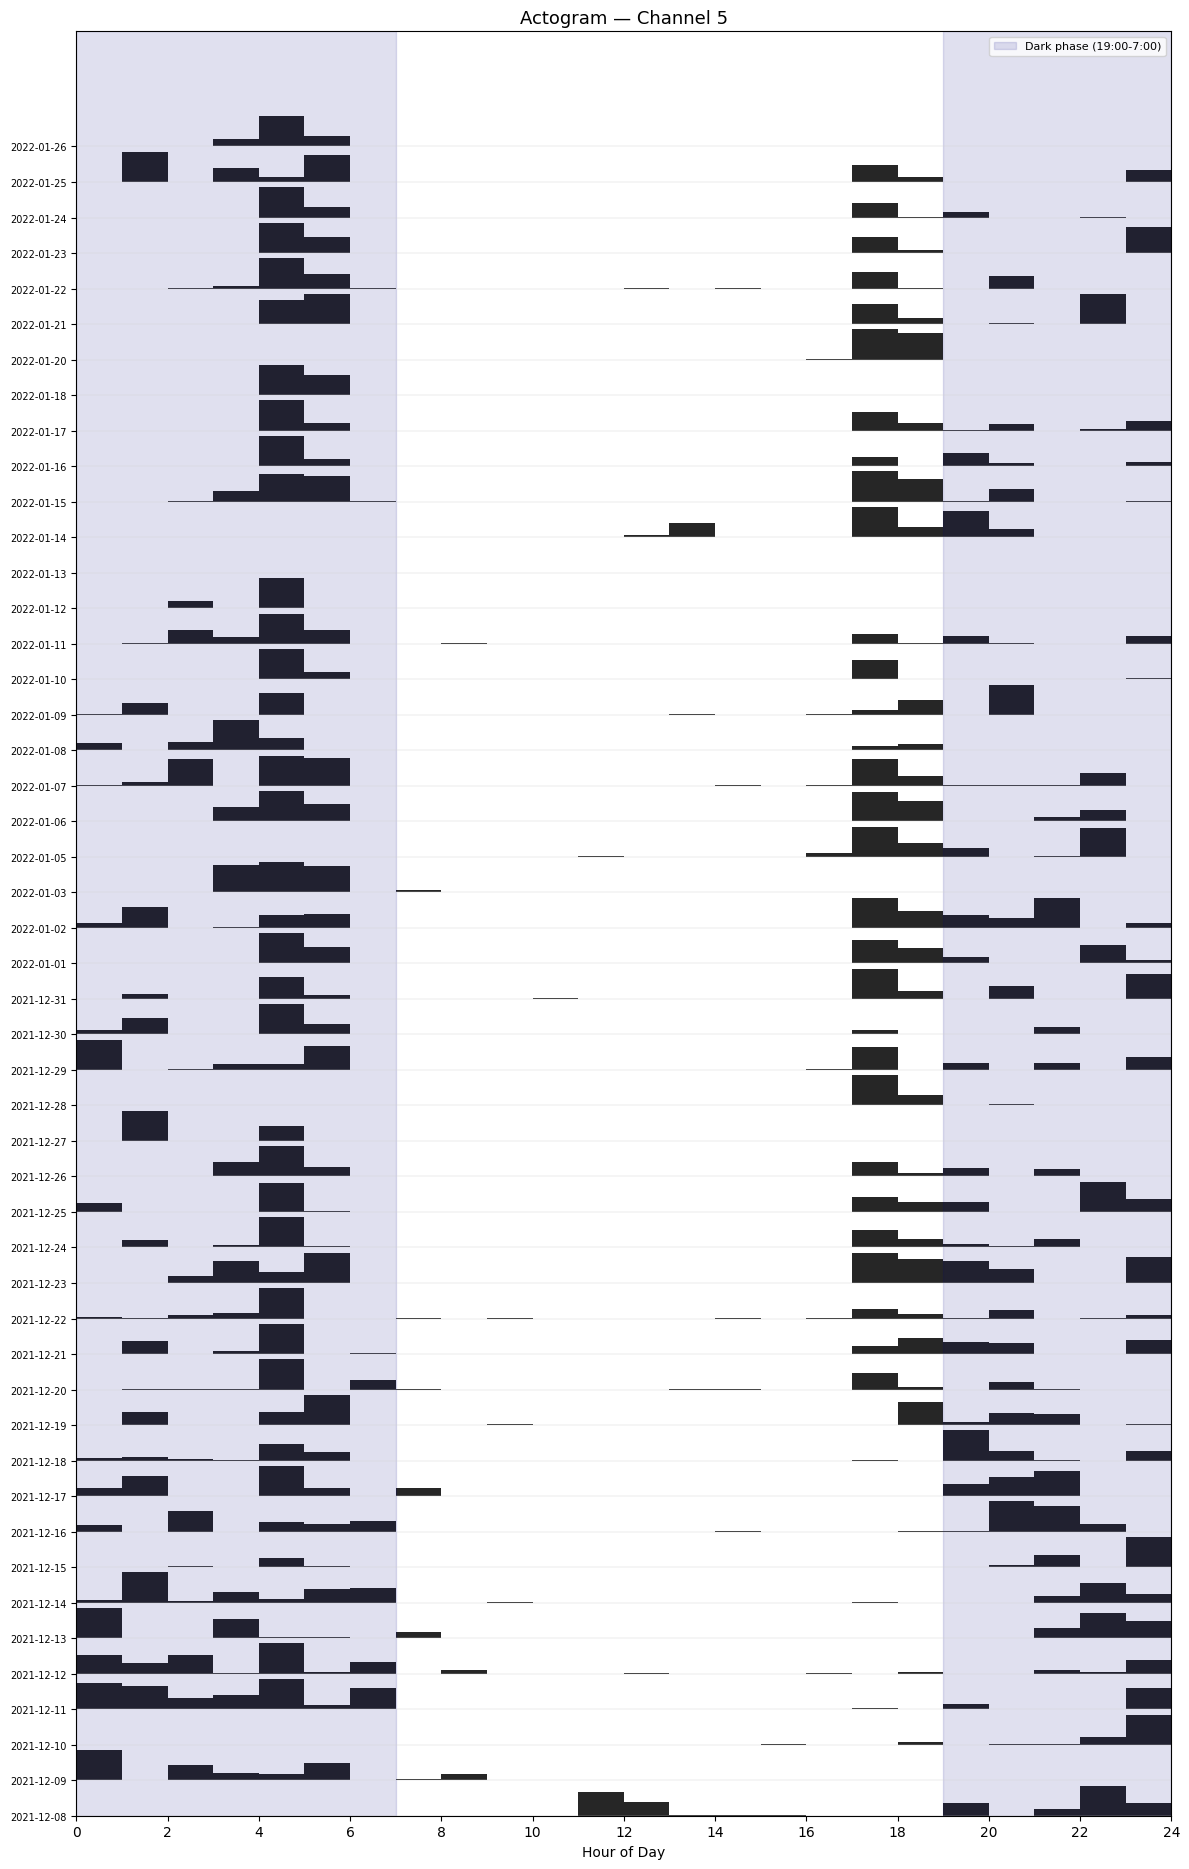

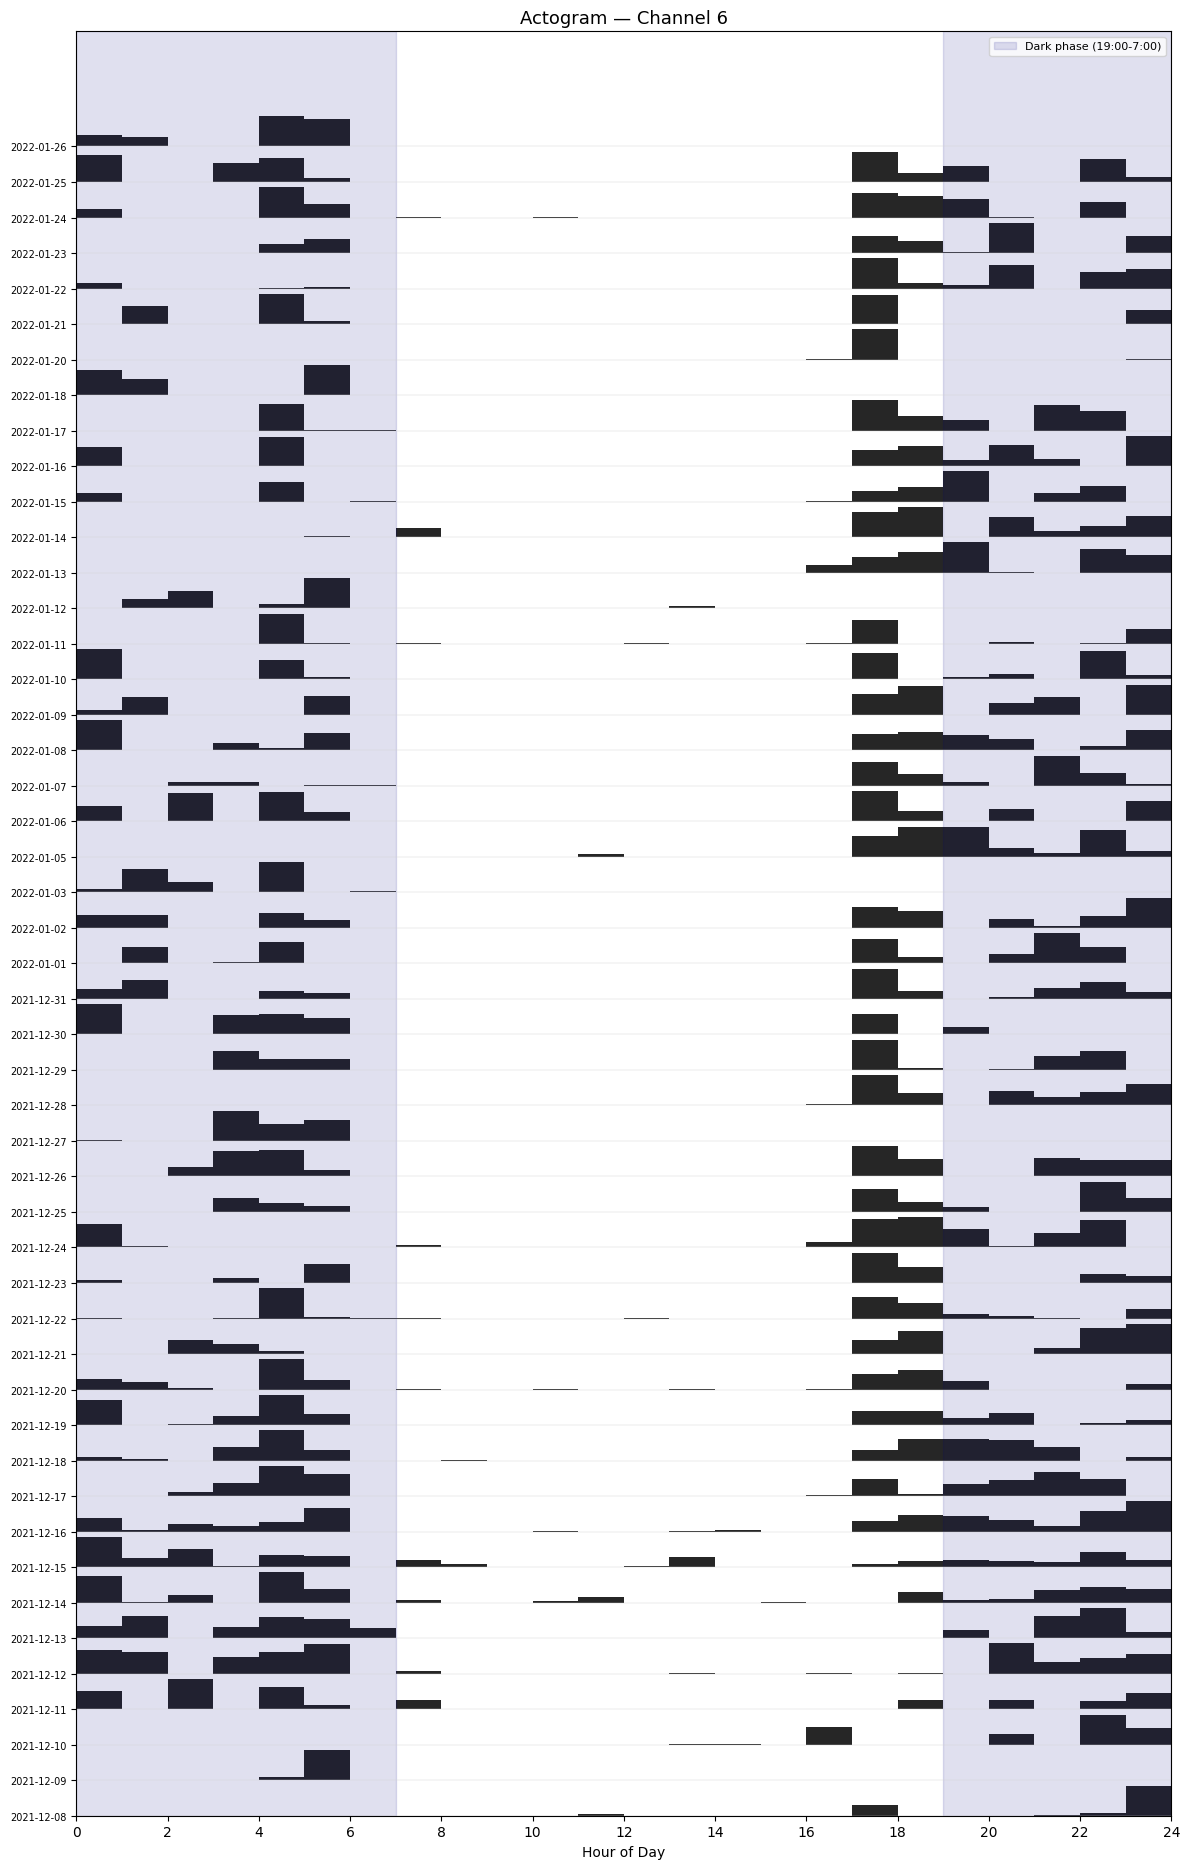

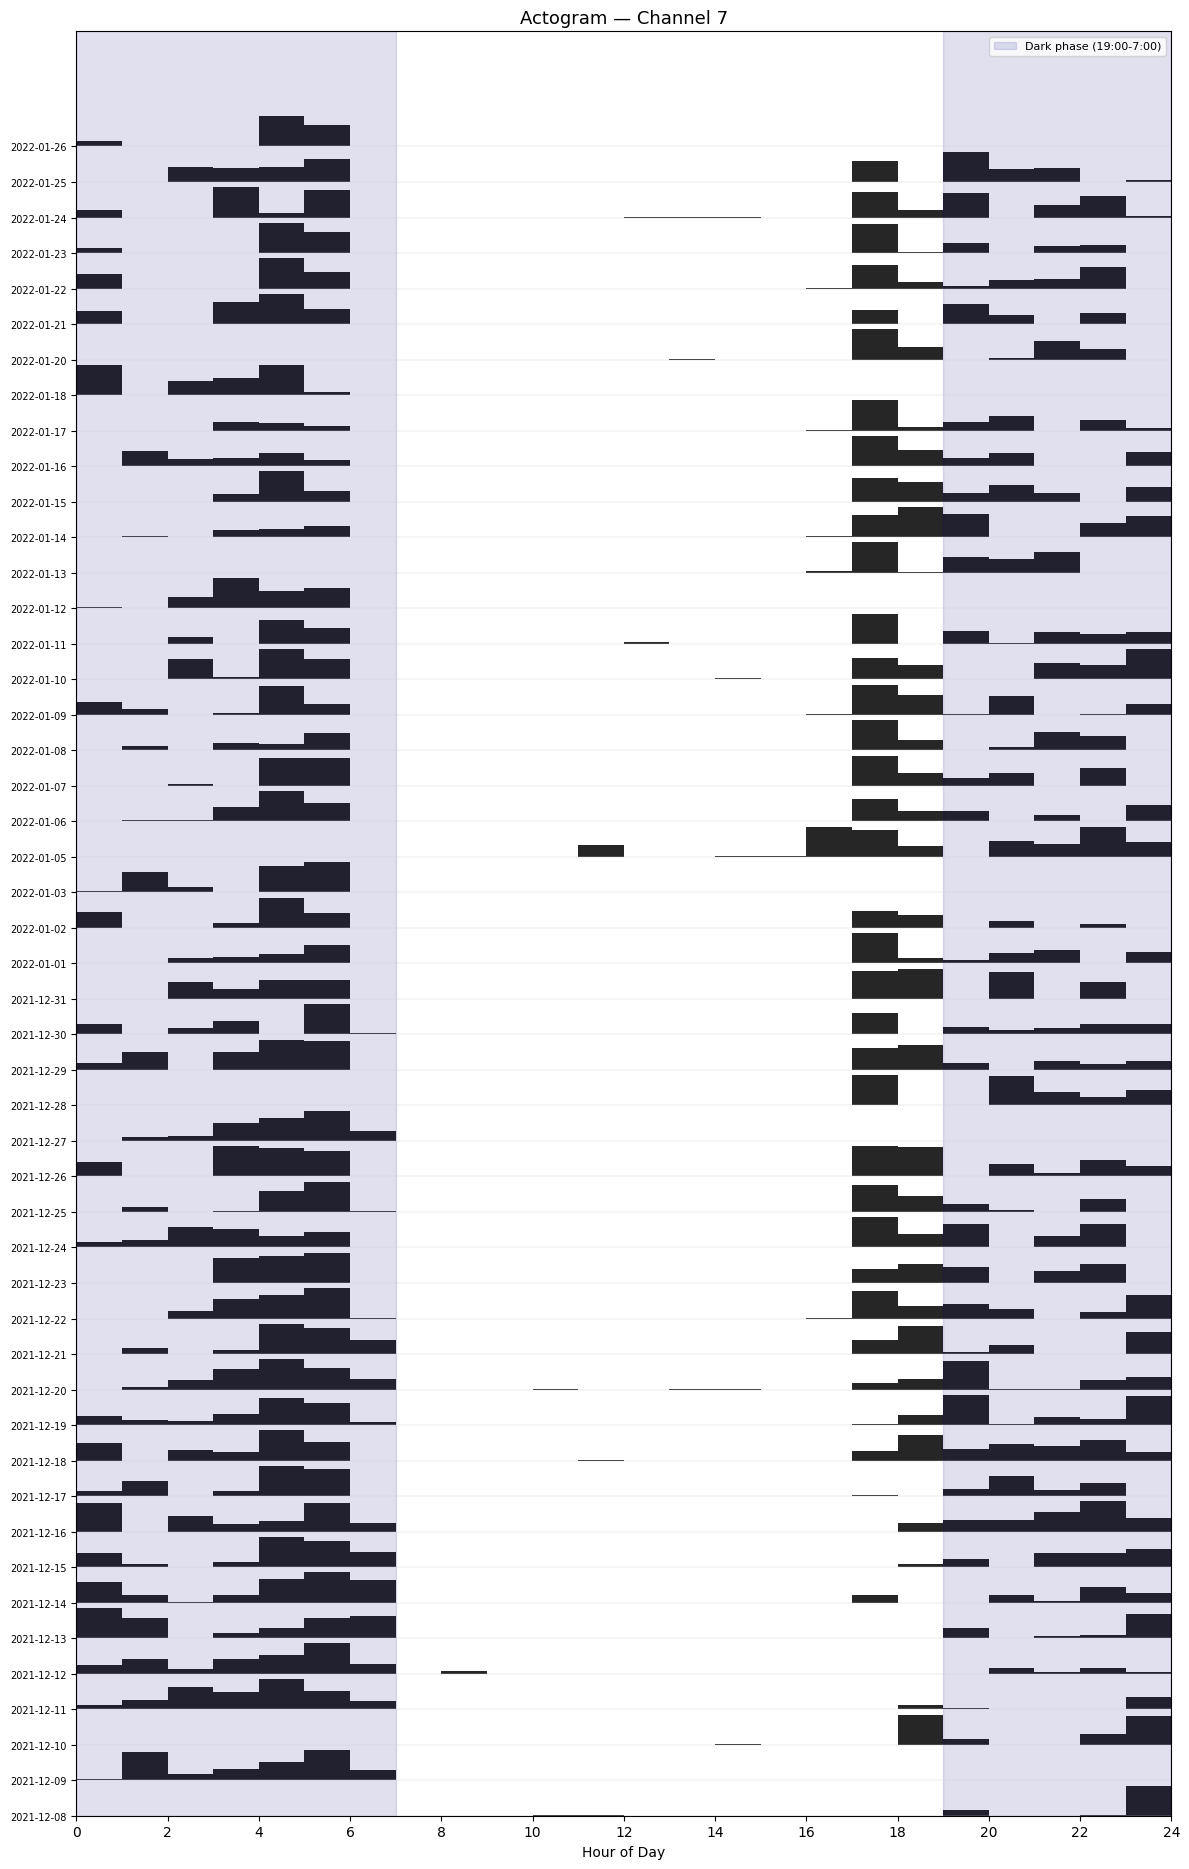

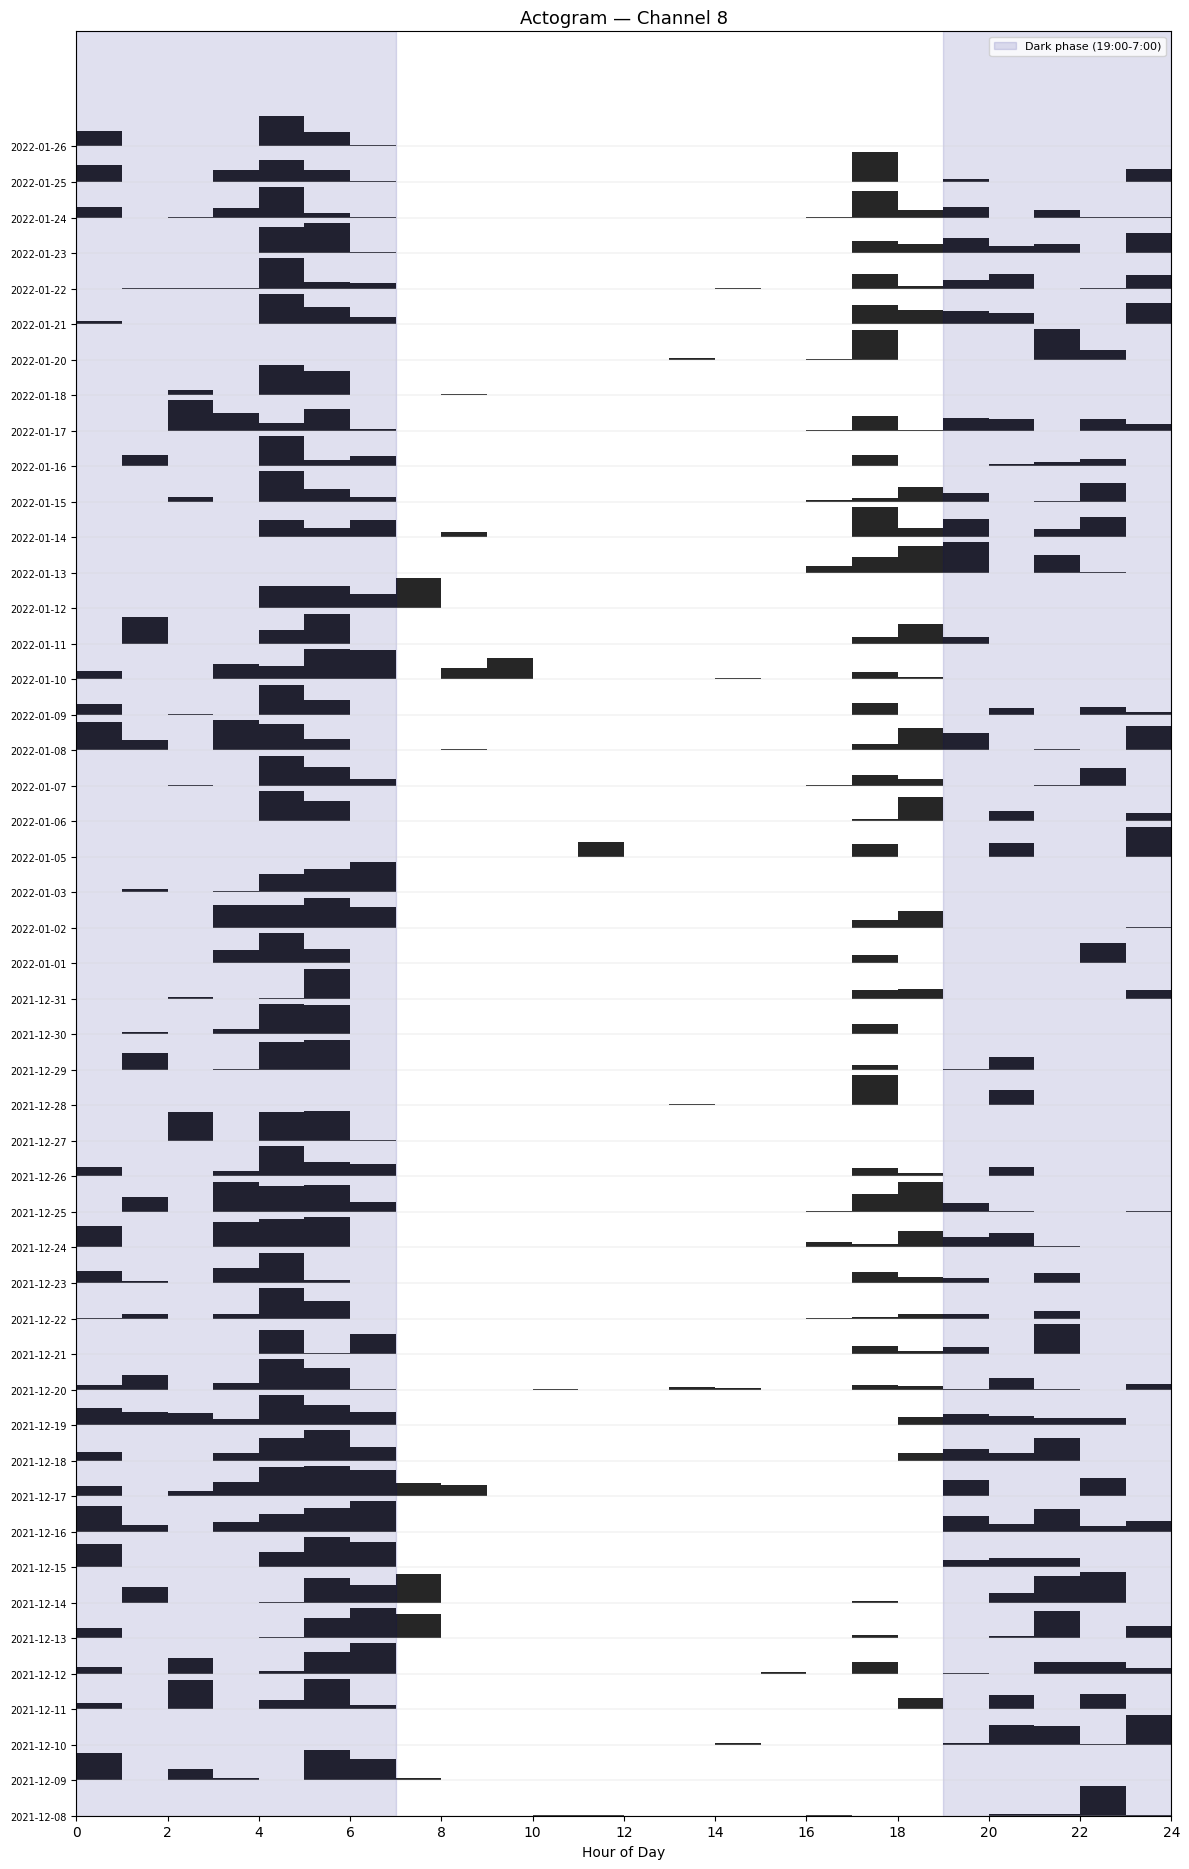

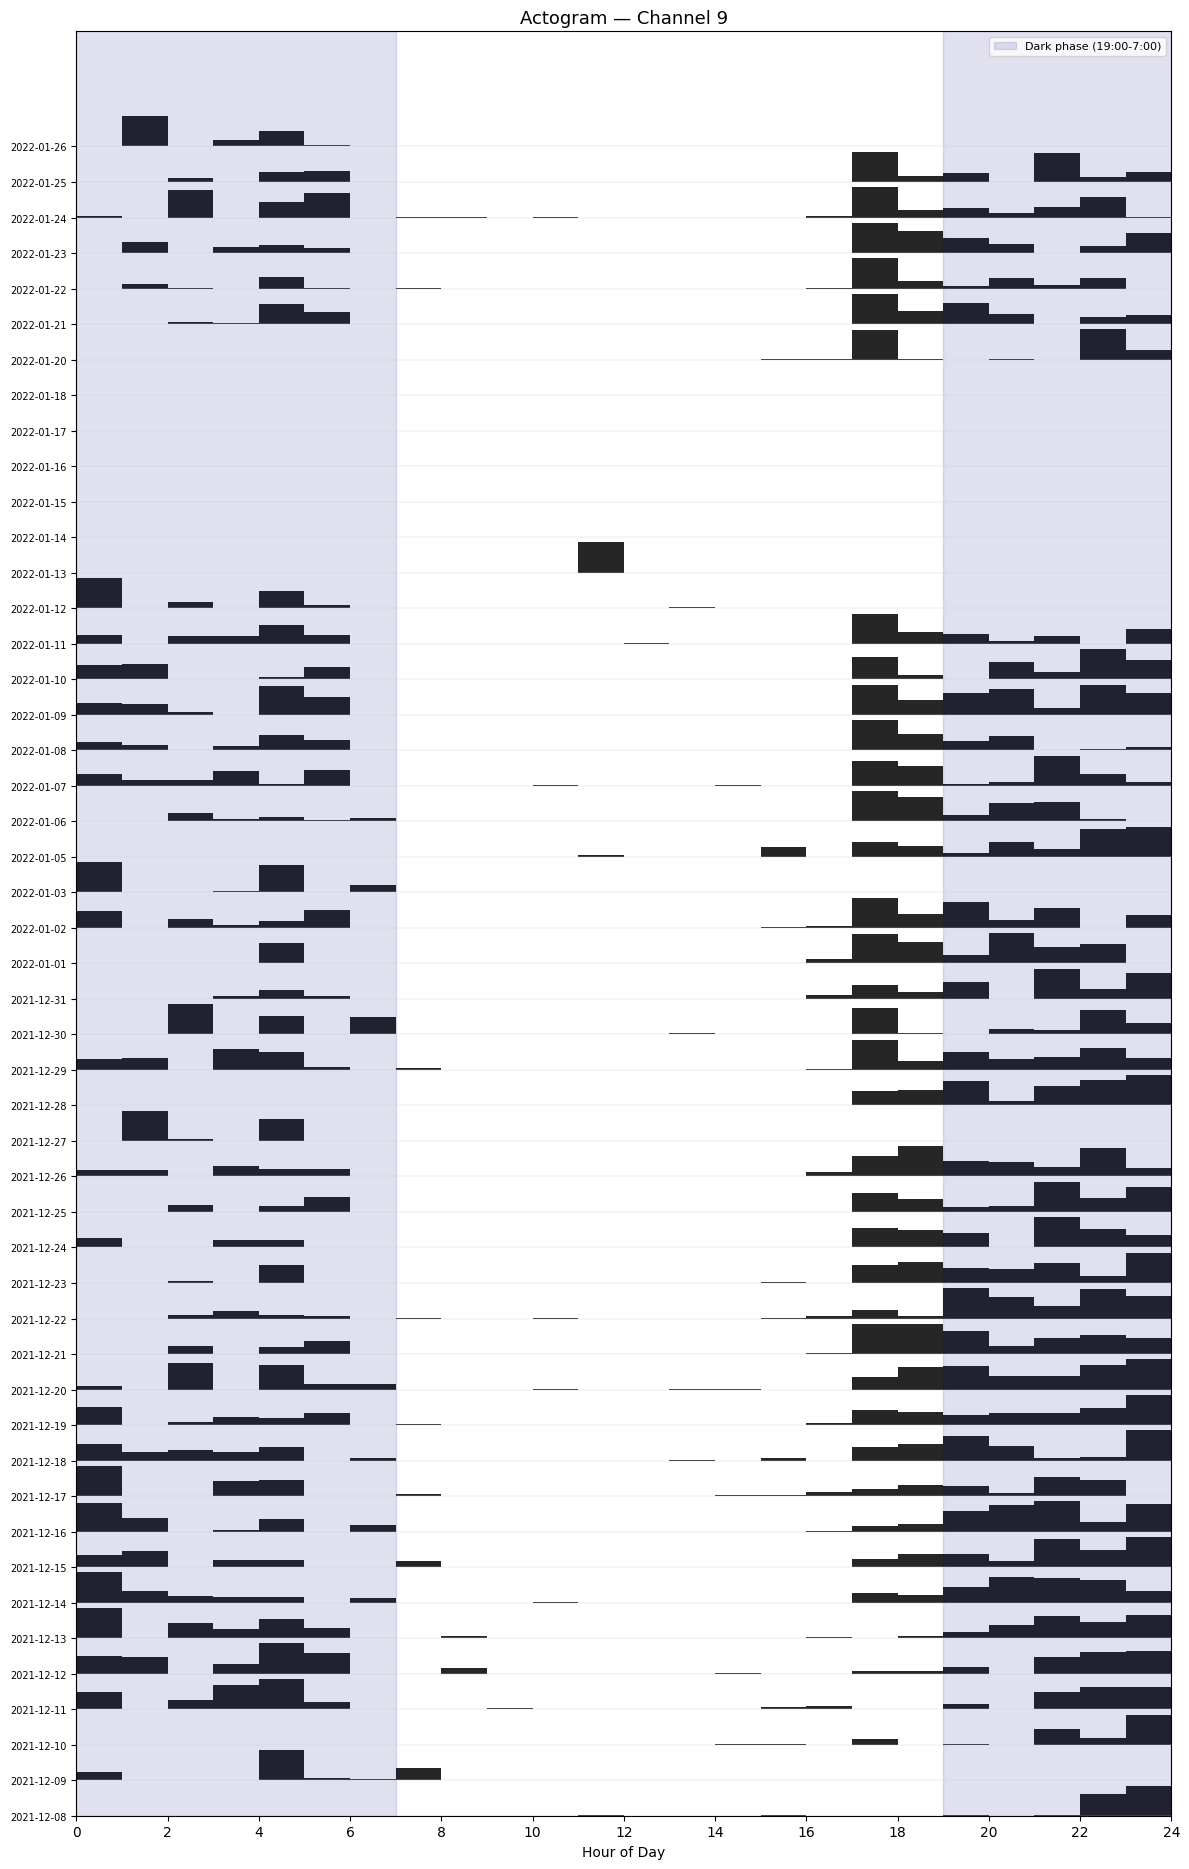

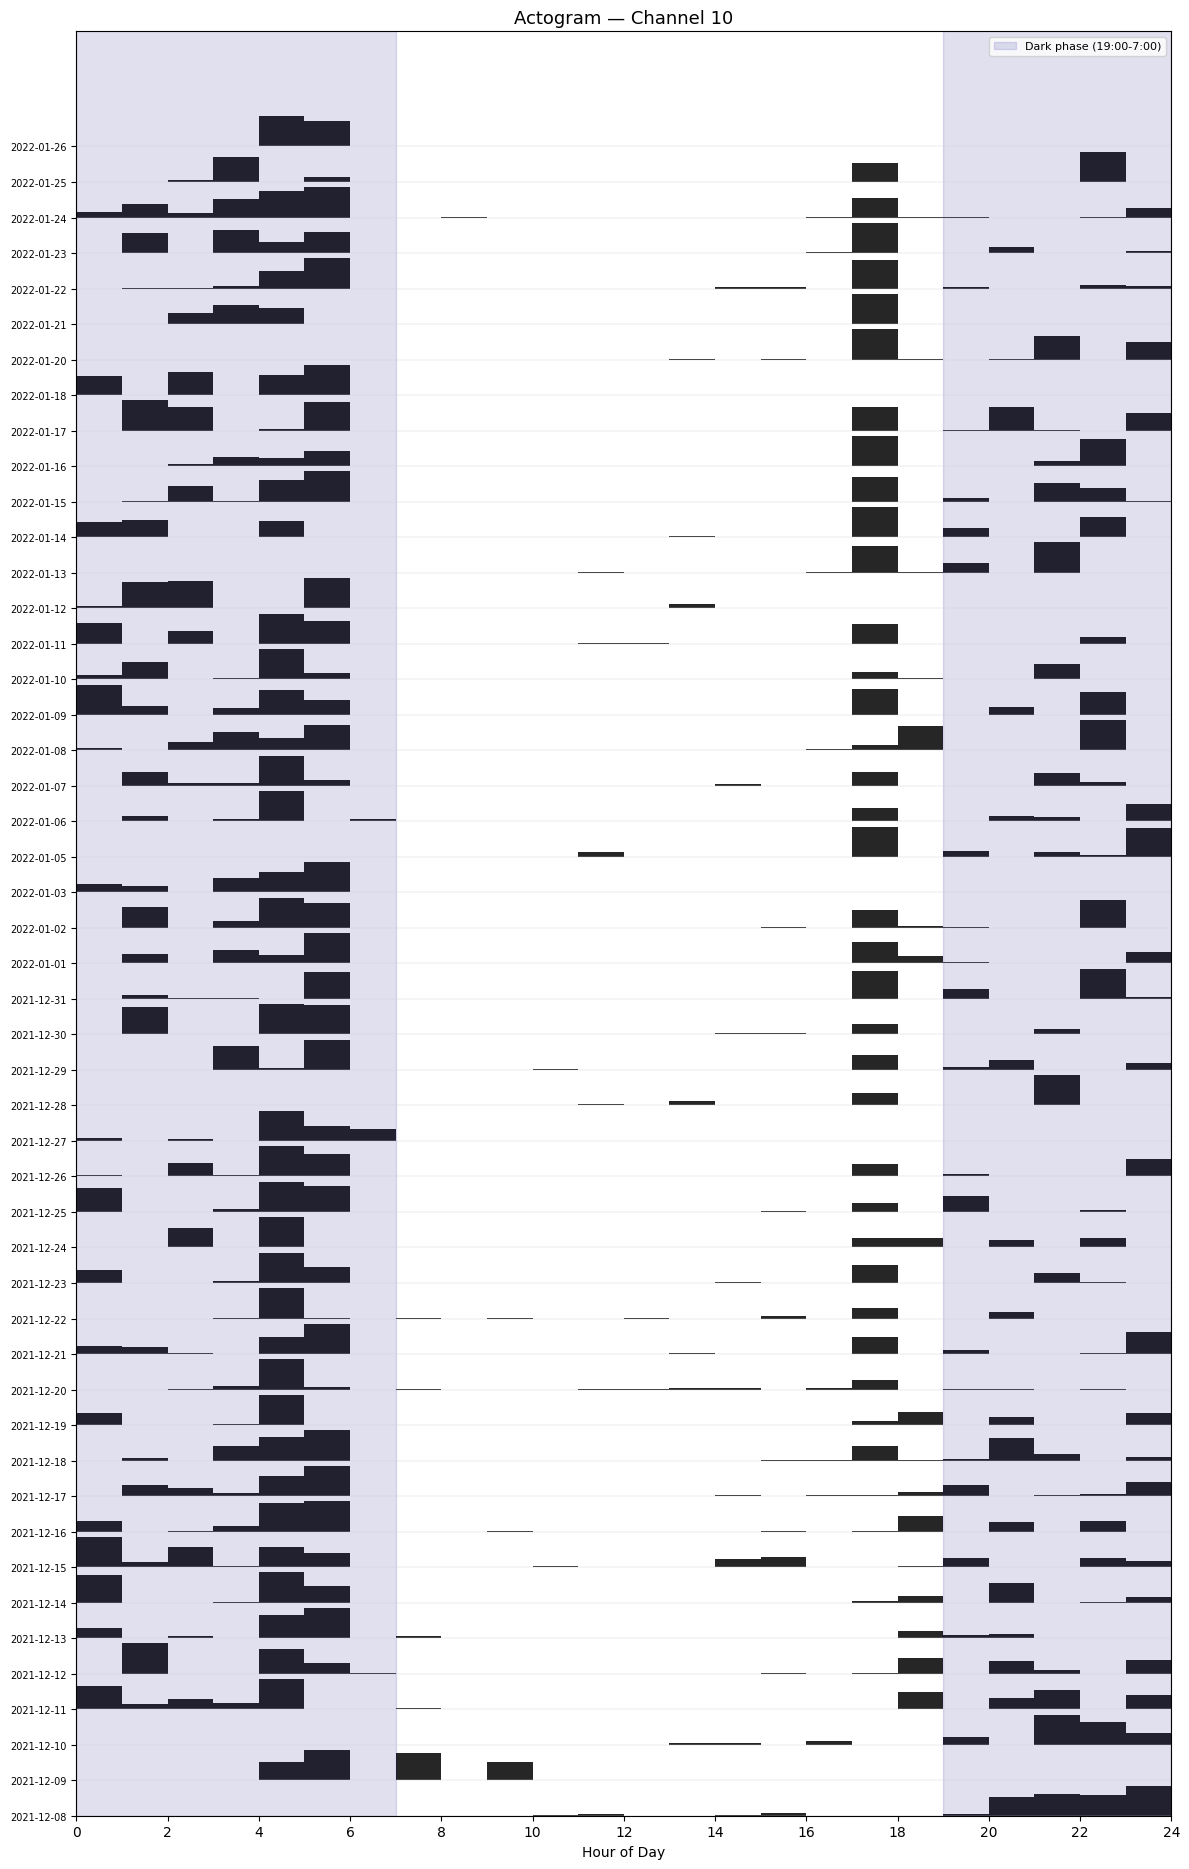

In [30]:
for ch in sorted(df_clean['Ch'].unique()):
    plot_actogram(df_clean[df_clean['Ch'] == ch], ch)

Correlation Heatmap 
- comparing amount of running at each hour across channels, might suggest some shared environemntal influence if they all peak at the same time, or more individual patterns if they differ

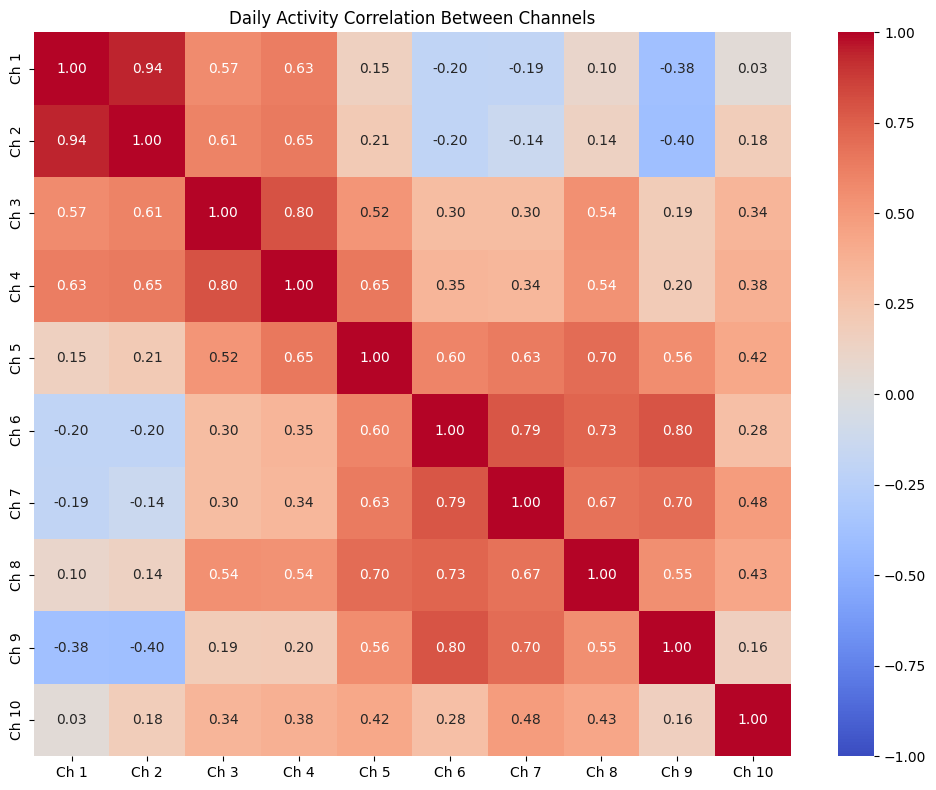

In [ ]:
import seaborn as sns

corr = pv_daily.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            xticklabels=[f'Ch {c}' for c in range(1,11)],
            yticklabels=[f'Ch {c}' for c in range(1,11)])
plt.title('Daily Activity Correlation Between Channels')
plt.tight_layout()
plt.show()